In [5]:
ACDC_TRAIN_ROOT = r"c:\Users\manoj\Desktop\Thesis\ACDC\ACDC\database\training"
ACDC_TEST_ROOT  = r"c:\Users\manoj\Desktop\Thesis\ACDC\ACDC\database\testing"

In [6]:
import os
import glob
import numpy as np
import nibabel as nib
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

In [7]:


import torch
import torch.nn as nn
import torch.nn.functional as F


# ────────────────────────────────────────────────
#               U-Net building blocks
# ────────────────────────────────────────────────

class DoubleConv(nn.Module):
    """(Conv → BN → ReLU) × 2"""
    def __init__(self, in_channels, out_channels, mid_channels=None):
        super().__init__()
        if mid_channels is None:
            mid_channels = out_channels

        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(mid_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.double_conv(x)


class Down(nn.Module):
    """Downscaling: MaxPool → DoubleConv"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels),
        )

    def forward(self, x):
        return self.maxpool_conv(x)


class Up(nn.Module):
    """Upscaling → concat → DoubleConv"""
    def __init__(self, in_channels, out_channels, bilinear=True):
        super().__init__()

        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=True)
            self.conv = DoubleConv(in_channels, out_channels, in_channels // 2)
        else:
            self.up = nn.ConvTranspose2d(
                in_channels, in_channels // 2, kernel_size=2, stride=2
            )
            self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)

        # Padding in case the in/out sizes mismatch
        diffY = x2.size(2) - x1.size(2)
        diffX = x2.size(3) - x1.size(3)

        x1 = F.pad(
            x1,
            [diffX // 2, diffX - diffX // 2,
             diffY // 2, diffY - diffY // 2]
        )

        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)


class OutConv(nn.Module):
    """Final 1×1 convolution"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x)


# ────────────────────────────────────────────────
#                   Full U-Net
# ────────────────────────────────────────────────

class UNet(nn.Module):
    """
    Standard U-Net (2D)
    Suitable for ACDC segmentation:
      - in_channels = 1
      - out_channels = 4 (BG, RV, MYO, LV)
    """
    def __init__(self, in_channels=1, out_channels=4, bilinear=False):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.bilinear = bilinear

        self.inc = DoubleConv(in_channels, 64)
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)

        factor = 2 if bilinear else 1
        self.down4 = Down(512, 1024 // factor)

        self.up1 = Up(1024, 512 // factor, bilinear)
        self.up2 = Up(512, 256 // factor, bilinear)
        self.up3 = Up(256, 128 // factor, bilinear)
        self.up4 = Up(128, 64, bilinear)

        self.outc = OutConv(64, out_channels)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)

        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)

        return self.outc(x)

In [8]:
# ============================================================
# ACDC MAIN DATA LOADER
# Self-contained, improved training loader, fixed 4-fold setup
# ============================================================

import os
import random
from pathlib import Path

import numpy as np
import nibabel as nib
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

ACDC_TRAINING_DIR = Path(r"c:\Users\manoj\Desktop\Thesis\ACDC\ACDC\database\training")

IMG_SIZE = 256
SEED = 0

TRAIN_BATCH_SIZE = 4
VAL_BATCH_SIZE = 8
NUM_WORKERS = 0

TRAIN_PHASE = "both"
TRAIN_SLICES_PER_PHASE = 2
TRAIN_PREFER_FG_PROB = 0.85
USE_AUGMENTATION = True


def read_ed_es(info_cfg_path: Path):
    ed = None
    es = None
    for line in info_cfg_path.read_text().splitlines():
        line = line.strip()
        if line.startswith("ED:"):
            ed = int(line.split(":")[1].strip())
        elif line.startswith("ES:"):
            es = int(line.split(":")[1].strip())
    if ed is None or es is None:
        raise ValueError(f"Missing ED/ES in {info_cfg_path}")
    return ed, es


def zscore(x: np.ndarray) -> np.ndarray:
    x = x.astype(np.float32)
    return (x - x.mean()) / (x.std() + 1e-8)


def get_ed_es_paths(patient_dir: Path):
    pid = patient_dir.name
    info = patient_dir / "Info.cfg"
    if not info.exists():
        raise FileNotFoundError(info)

    ed, es = read_ed_es(info)

    ed_img = patient_dir / f"{pid}_frame{ed:02d}.nii.gz"
    ed_msk = patient_dir / f"{pid}_frame{ed:02d}_gt.nii.gz"
    es_img = patient_dir / f"{pid}_frame{es:02d}.nii.gz"
    es_msk = patient_dir / f"{pid}_frame{es:02d}_gt.nii.gz"

    for p in (ed_img, ed_msk, es_img, es_msk):
        if not p.exists():
            raise FileNotFoundError(p)

    return ed_img, ed_msk, es_img, es_msk


def resize_img_mask(img_2d: np.ndarray, msk_2d: np.ndarray, img_size: int):
    img = torch.from_numpy(img_2d).float().unsqueeze(0).unsqueeze(0)
    msk = torch.from_numpy(msk_2d.astype(np.int64)).unsqueeze(0).unsqueeze(0).float()

    img = F.interpolate(img, size=(img_size, img_size), mode="bilinear", align_corners=False)
    msk = F.interpolate(msk, size=(img_size, img_size), mode="nearest")

    img = img.squeeze(0)
    msk = msk.squeeze(0).squeeze(0).long()
    return img, msk


def patient_dir_from_id(root: Path, pid0: int) -> Path:
    if pid0 < 0:
        raise ValueError("pid0 must be >= 0")
    return root / f"patient{pid0 + 1:03d}"


class SegmentationAugmentor:
    def __init__(self, p_flip=0.5, p_rot90=0.5, p_intensity=0.5, p_noise=0.3):
        self.p_flip = p_flip
        self.p_rot90 = p_rot90
        self.p_intensity = p_intensity
        self.p_noise = p_noise

    def __call__(self, image, mask):
        if random.random() < self.p_flip:
            image = torch.flip(image, dims=[2])
            mask = torch.flip(mask, dims=[1])

        if random.random() < self.p_flip:
            image = torch.flip(image, dims=[1])
            mask = torch.flip(mask, dims=[0])

        if random.random() < self.p_rot90:
            k = random.randint(0, 3)
            image = torch.rot90(image, k, dims=[1, 2])
            mask = torch.rot90(mask, k, dims=[0, 1])

        if random.random() < self.p_intensity:
            scale = random.uniform(0.9, 1.1)
            shift = random.uniform(-0.1, 0.1)
            image = image * scale + shift

        if random.random() < self.p_noise:
            noise = torch.randn_like(image) * 0.03
            image = image + noise

        return image, mask


class ACDCTrainRandomSlice(Dataset):
    def __init__(
        self,
        patient_dirs,
        img_size=256,
        phase="both",
        seed=0,
        slices_per_phase=2,
        prefer_fg_prob=0.85,
        augment=None
    ):
        self.patient_dirs = list(patient_dirs)
        self.img_size = img_size
        self.phase = phase.lower()
        self.rng = random.Random(seed)
        self.slices_per_phase = slices_per_phase
        self.prefer_fg_prob = prefer_fg_prob
        self.augment = augment

        self.base_samples = []

        for pd in self.patient_dirs:
            ed_img, ed_msk, es_img, es_msk = get_ed_es_paths(pd)

            if self.phase in ("ed", "both"):
                self.base_samples.append((ed_img, ed_msk, "ED", pd.name))

            if self.phase in ("es", "both"):
                self.base_samples.append((es_img, es_msk, "ES", pd.name))

    def __len__(self):
        return len(self.base_samples) * self.slices_per_phase

    def _choose_slice_index(self, mask_vol):
        S = mask_vol.shape[2]
        fg_slices = [s for s in range(S) if np.max(mask_vol[:, :, s]) > 0]

        if len(fg_slices) > 0 and self.rng.random() < self.prefer_fg_prob:
            return self.rng.choice(fg_slices)

        return self.rng.randint(0, S - 1)

    def __getitem__(self, idx):
        base_idx = idx % len(self.base_samples)
        img_path, msk_path, phase_name, patient_name = self.base_samples[base_idx]

        vol = nib.load(str(img_path)).get_fdata()
        msk = nib.load(str(msk_path)).get_fdata()

        s = self._choose_slice_index(msk)

        img2d = zscore(vol[:, :, s])
        msk2d = np.clip(msk[:, :, s].astype(np.int64), 0, 3)

        img, mask = resize_img_mask(img2d, msk2d, self.img_size)

        if self.augment is not None:
            img, mask = self.augment(img, mask)

        return {
            "image": img,
            "mask": mask,
            "meta": {
                "patient": patient_name,
                "phase": phase_name,
                "slice": int(s)
            }
        }


class ACDCEvalAllSlices(Dataset):
    def __init__(self, patient_dirs, img_size=256, phase="both", cache=True):
        self.patient_dirs = list(patient_dirs)
        self.img_size = img_size
        self.phase = phase.lower()
        self.cache = {} if cache else None
        self.index = []

        for pd in self.patient_dirs:
            ed_img, ed_msk, es_img, es_msk = get_ed_es_paths(pd)
            ed_vol = nib.load(str(ed_img)).get_fdata()
            S = ed_vol.shape[2]

            if self.phase in ("ed", "both"):
                for s in range(S):
                    self.index.append((pd, "ED", s))

            if self.phase in ("es", "both"):
                for s in range(S):
                    self.index.append((pd, "ES", s))

    def __len__(self):
        return len(self.index)

    def _load_patient(self, pd: Path):
        pid = pd.name
        if self.cache is not None and pid in self.cache:
            return self.cache[pid]

        ed_img, ed_msk, es_img, es_msk = get_ed_es_paths(pd)

        ed_vol = nib.load(str(ed_img)).get_fdata()
        ed_gt = nib.load(str(ed_msk)).get_fdata()
        es_vol = nib.load(str(es_img)).get_fdata()
        es_gt = nib.load(str(es_msk)).get_fdata()

        data = (ed_vol, ed_gt, es_vol, es_gt)

        if self.cache is not None:
            self.cache[pid] = data

        return data

    def __getitem__(self, idx):
        pd, phase, s = self.index[idx]
        pid = pd.name

        ed_vol, ed_gt, es_vol, es_gt = self._load_patient(pd)

        if phase == "ED":
            img2d = zscore(ed_vol[:, :, s])
            msk2d = np.clip(ed_gt[:, :, s].astype(np.int64), 0, 3)
        else:
            img2d = zscore(es_vol[:, :, s])
            msk2d = np.clip(es_gt[:, :, s].astype(np.int64), 0, 3)

        img, mask = resize_img_mask(img2d, msk2d, self.img_size)

        return {
            "image": img,
            "mask": mask,
            "meta": {
                "patient": pid,
                "phase": phase,
                "slice": int(s)
            }
        }


train_ids_fold0 = [1,2,3,4,5,7,8,9,10,11,12,13,15,18,19,21,22,25,26,27,28,29,30,31,32,33,35,37,38,39,40,41,42,43,44,45,46,47,48,49,52,53,54,55,58,60,61,65,66,67,68,69,71,72,73,74,75,76,77,78,80,81,82,83,84,85,86,87,88,89,90,92,94,96,97]
val_ids_fold0   = [0,6,14,16,17,20,23,24,34,36,50,51,56,57,59,62,63,64,70,79,91,93,95,98,99]

train_ids_fold1 = [0,1,2,4,6,7,8,9,10,11,12,14,16,17,18,20,21,22,23,24,25,26,27,28,31,33,34,35,36,37,40,41,42,43,44,45,48,49,50,51,55,56,57,58,59,62,63,64,65,66,67,68,70,71,72,73,74,76,77,79,83,84,85,87,88,90,91,92,93,94,95,96,97,98,99]
val_ids_fold1   = [3,5,13,15,19,29,30,32,38,39,46,47,52,53,54,60,61,69,75,78,80,81,82,86,89]

train_ids_fold2 = [0,1,3,5,6,7,8,10,13,14,15,16,17,18,19,20,23,24,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,46,47,48,49,50,51,52,53,54,56,57,59,60,61,62,63,64,65,66,68,69,70,72,74,75,78,79,80,81,82,85,86,89,90,91,92,93,94,95,96,98,99]
val_ids_fold2   = [2,4,9,11,12,21,22,25,26,27,43,44,45,55,58,67,71,73,76,77,83,84,87,88,97]

train_ids_fold3 = [0,2,3,4,5,6,9,11,12,13,14,15,16,17,19,20,21,22,23,24,25,26,27,29,30,32,34,36,38,39,43,44,45,46,47,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,67,69,70,71,73,75,76,77,78,79,80,81,82,83,84,86,87,88,89,91,93,95,97,98,99]
val_ids_fold3   = [1,7,8,10,18,28,31,33,35,37,40,41,42,48,49,65,66,68,72,74,85,90,92,94,96]

FOLDS = [
    (train_ids_fold0, val_ids_fold0),
    (train_ids_fold1, val_ids_fold1),
    (train_ids_fold2, val_ids_fold2),
    (train_ids_fold3, val_ids_fold3),
]


def build_fold_loaders(
    fold_idx=0,
    img_size=256,
    train_bs=4,
    val_bs=8,
    num_workers=0,
    phase="both",
    seed=0,
    slices_per_phase=2,
    prefer_fg_prob=0.85,
    use_augmentation=True
):
    train_ids, val_ids = FOLDS[fold_idx]

    train_patients = [patient_dir_from_id(ACDC_TRAINING_DIR, i) for i in train_ids]
    val_patients = [patient_dir_from_id(ACDC_TRAINING_DIR, i) for i in val_ids]

    augmentor = SegmentationAugmentor() if use_augmentation else None

    train_dataset = ACDCTrainRandomSlice(
        train_patients,
        img_size=img_size,
        phase=phase,
        seed=seed + fold_idx,
        slices_per_phase=slices_per_phase,
        prefer_fg_prob=prefer_fg_prob,
        augment=augmentor
    )

    val_dataset = ACDCEvalAllSlices(
        val_patients,
        img_size=img_size,
        phase=phase,
        cache=True
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=train_bs,
        shuffle=True,
        num_workers=num_workers,
        drop_last=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=val_bs,
        shuffle=False,
        num_workers=num_workers,
        drop_last=False
    )

    return train_loader, val_loader, train_patients, val_patients, train_dataset, val_dataset


fold_idx = 0

train_loader, val_loader, train_patients, val_patients, train_dataset, val_dataset = build_fold_loaders(
    fold_idx=fold_idx,
    img_size=IMG_SIZE,
    train_bs=TRAIN_BATCH_SIZE,
    val_bs=VAL_BATCH_SIZE,
    num_workers=NUM_WORKERS,
    phase=TRAIN_PHASE,
    seed=SEED,
    slices_per_phase=TRAIN_SLICES_PER_PHASE,
    prefer_fg_prob=TRAIN_PREFER_FG_PROB,
    use_augmentation=USE_AUGMENTATION
)

print(f"Fold: {fold_idx}")
print(f"Train patients: {len(train_patients)} | Val patients: {len(val_patients)}")
print(f"Train samples: {len(train_dataset)} | Val samples: {len(val_dataset)}")
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

b = next(iter(train_loader))
print(
    "TRAIN batch -> image:", b["image"].shape,
    "mask:", b["mask"].shape,
    "mask dtype:", b["mask"].dtype,
    "mask unique:", torch.unique(b["mask"])[:10]
)

vb = next(iter(val_loader))
print(
    "VAL batch -> image:", vb["image"].shape,
    "mask:", vb["mask"].shape,
    "example meta:", vb["meta"]["patient"][0], vb["meta"]["phase"][0], int(vb["meta"]["slice"][0])
)

Fold: 0
Train patients: 75 | Val patients: 25
Train samples: 300 | Val samples: 492
Train batches: 75 | Val batches: 62
TRAIN batch -> image: torch.Size([4, 1, 256, 256]) mask: torch.Size([4, 256, 256]) mask dtype: torch.int64 mask unique: tensor([0, 1, 2, 3])
VAL batch -> image: torch.Size([8, 1, 256, 256]) mask: torch.Size([8, 256, 256]) example meta: patient001 ED 0


In [ ]:
# ============================================================
# ACDC MAIN TRAINING CELL
# 4-fold U-Net training with versioned saving
# ============================================================

import json
import copy
import random
from datetime import datetime
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Experiment settings
# ------------------------------------------------------------
EXPERIMENT_NAME = "unet_main_aug_fg_2slice"
EXPERIMENT_NOTE = "Standard U-Net with foreground-aware slice sampling, augmentation, and 2 slices per phase"

MAX_EPOCHS = 60
LR = 1e-4
PATIENCE = 12
MIN_DELTA = 1e-4

LAMBDA_DICE = 1.0
N_CLASSES = 4
CLASS_NAMES = ["BG", "RV", "MYO", "LV"]

# These match your loader cell
IMG_SIZE = 256
TRAIN_BATCH_SIZE = 4
VAL_BATCH_SIZE = 8
NUM_WORKERS = 0
TRAIN_PHASE = "both"
TRAIN_SLICES_PER_PHASE = 2
TRAIN_PREFER_FG_PROB = 0.85
USE_AUGMENTATION = True
SEED = 0

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ------------------------------------------------------------
# Versioned save folder
# ------------------------------------------------------------
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
RUNS_ROOT = Path("./runs_acdc_segmentation_experiments")
RUNS_DIR = RUNS_ROOT / f"{EXPERIMENT_NAME}_{timestamp}"
RUNS_DIR.mkdir(parents=True, exist_ok=True)

print("Experiment folder:", RUNS_DIR.resolve())

experiment_config = {
    "experiment_name": EXPERIMENT_NAME,
    "experiment_note": EXPERIMENT_NOTE,
    "timestamp": timestamp,
    "max_epochs": MAX_EPOCHS,
    "lr": LR,
    "patience": PATIENCE,
    "min_delta": MIN_DELTA,
    "lambda_dice": LAMBDA_DICE,
    "n_classes": N_CLASSES,
    "class_names": CLASS_NAMES,
    "img_size": IMG_SIZE,
    "train_batch_size": TRAIN_BATCH_SIZE,
    "val_batch_size": VAL_BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "train_phase": TRAIN_PHASE,
    "train_slices_per_phase": TRAIN_SLICES_PER_PHASE,
    "train_prefer_fg_prob": TRAIN_PREFER_FG_PROB,
    "use_augmentation": USE_AUGMENTATION,
    "seed": SEED,
    "training_dir": str(ACDC_TRAINING_DIR),
}
with open(RUNS_DIR / "experiment_config.json", "w", encoding="utf-8") as f:
    json.dump(experiment_config, f, indent=2)

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------
def compute_confusion_matrix(true_flat: np.ndarray, pred_flat: np.ndarray, n_classes: int) -> np.ndarray:
    true_flat = true_flat.astype(np.int64)
    pred_flat = pred_flat.astype(np.int64)
    k = true_flat * n_classes + pred_flat
    binc = np.bincount(k, minlength=n_classes * n_classes)
    return binc.reshape(n_classes, n_classes)

def dice_from_cm(cm: np.ndarray, eps: float = 1e-6):
    dice = np.zeros(cm.shape[0], dtype=np.float32)
    for c in range(cm.shape[0]):
        tp = cm[c, c]
        fp = cm[:, c].sum() - tp
        fn = cm[c, :].sum() - tp
        dice[c] = (2 * tp + eps) / (2 * tp + fp + fn + eps)
    fg_dice = float(dice[1:].mean())
    return dice, fg_dice

def row_norm_dec(cm: np.ndarray):
    cm = cm.astype(np.float64)
    rs = cm.sum(axis=1, keepdims=True) + 1e-12
    return cm / rs

def save_csv_matrix(path: Path, mat: np.ndarray, class_names):
    header = ",".join(["true/pred"] + list(class_names))
    lines = [header]
    for i, row in enumerate(mat):
        lines.append(",".join([class_names[i]] + [f"{v:.6f}" for v in row]))
    path.write_text("\n".join(lines), encoding="utf-8")

def mean_std(x):
    x = np.array(x, dtype=np.float64)
    mean = float(np.mean(x))
    std = float(np.std(x, ddof=1)) if len(x) > 1 else 0.0
    return mean, std

# ------------------------------------------------------------
# Plot helpers
# ------------------------------------------------------------
def save_loss_curve(train_loss, val_loss, outpath: Path, title: str):
    x = np.arange(1, len(train_loss) + 1)
    plt.figure(figsize=(7, 4))
    plt.plot(x, train_loss, label="Train Loss")
    plt.plot(x, val_loss, label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(outpath, dpi=250)
    plt.close()

def save_fg_dice_curve(val_fg_dice, outpath: Path, title: str):
    x = np.arange(1, len(val_fg_dice) + 1)
    plt.figure(figsize=(7, 4))
    plt.plot(x, val_fg_dice, label="Val FG Dice")
    plt.xlabel("Epoch")
    plt.ylabel("Dice")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(outpath, dpi=250)
    plt.close()

def save_class_dice_curve(dice_bg, dice_rv, dice_myo, dice_lv, outpath: Path, title: str):
    x = np.arange(1, len(dice_bg) + 1)
    plt.figure(figsize=(8, 4))
    plt.plot(x, dice_bg, label="BG")
    plt.plot(x, dice_rv, label="RV")
    plt.plot(x, dice_myo, label="MYO")
    plt.plot(x, dice_lv, label="LV")
    plt.xlabel("Epoch")
    plt.ylabel("Dice")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(outpath, dpi=250)
    plt.close()

# ------------------------------------------------------------
# Loss
# ------------------------------------------------------------
class SoftDiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        c = logits.shape[1]
        probs = torch.softmax(logits, dim=1)
        targets_1h = torch.nn.functional.one_hot(targets, num_classes=c).permute(0, 3, 1, 2).float()

        probs = probs[:, 1:, :, :]
        targets_1h = targets_1h[:, 1:, :, :]

        dims = (0, 2, 3)
        inter = torch.sum(probs * targets_1h, dims)
        denom = torch.sum(probs + targets_1h, dims)
        dice = (2.0 * inter + self.smooth) / (denom + self.smooth)
        return 1.0 - dice.mean()

ce_loss = nn.CrossEntropyLoss()
dice_loss = SoftDiceLoss()

# ------------------------------------------------------------
# Train / validation
# ------------------------------------------------------------
def train_one_epoch(model, loader, optimizer):
    model.train()
    running_loss = 0.0
    n_batches = 0

    for batch in loader:
        images = batch["image"].to(device, dtype=torch.float32)
        masks = batch["mask"].to(device, dtype=torch.long)

        optimizer.zero_grad(set_to_none=True)
        logits = model(images)
        loss = ce_loss(logits, masks) + LAMBDA_DICE * dice_loss(logits, masks)
        loss.backward()
        optimizer.step()

        running_loss += float(loss.item())
        n_batches += 1

    return running_loss / max(1, n_batches)

@torch.no_grad()
def validate_one_epoch(model, loader):
    model.eval()
    running_loss = 0.0
    n_batches = 0
    cm = np.zeros((N_CLASSES, N_CLASSES), dtype=np.int64)

    for batch in loader:
        images = batch["image"].to(device, dtype=torch.float32)
        masks = batch["mask"].to(device, dtype=torch.long)

        logits = model(images)
        loss = ce_loss(logits, masks) + LAMBDA_DICE * dice_loss(logits, masks)

        running_loss += float(loss.item())
        n_batches += 1

        pred = torch.argmax(logits, dim=1)
        true_flat = masks.view(-1).cpu().numpy()
        pred_flat = pred.view(-1).cpu().numpy()
        cm += compute_confusion_matrix(true_flat, pred_flat, N_CLASSES)

    val_loss = running_loss / max(1, n_batches)
    dice, fg_dice = dice_from_cm(cm)
    return val_loss, cm, dice, fg_dice

# ------------------------------------------------------------
# Main 4-fold training
# ------------------------------------------------------------
cv_summary = []

for fold_idx in range(len(FOLDS)):
    print("\n" + "=" * 90)
    print(f"Fold {fold_idx} | {EXPERIMENT_NAME}")
    print("=" * 90)

    set_seed(SEED + fold_idx)

    fold_dir = RUNS_DIR / f"fold_{fold_idx:02d}"
    fold_dir.mkdir(parents=True, exist_ok=True)

    best_ckpt_path = fold_dir / f"{EXPERIMENT_NAME}_best_fold{fold_idx}.pth"
    last_ckpt_path = fold_dir / f"{EXPERIMENT_NAME}_last_fold{fold_idx}.pth"
    history_csv_path = fold_dir / "history_epoch_metrics.csv"
    summary_txt_path = fold_dir / "summary_best_validation.txt"
    cm_counts_csv_path = fold_dir / "confusion_counts.csv"
    cm_dec_csv_path = fold_dir / "confusion_row_decimal.csv"
    loss_fig_path = fold_dir / "curve_loss.png"
    fg_dice_fig_path = fold_dir / "curve_fg_dice.png"
    class_dice_fig_path = fold_dir / "curve_dice_per_class.png"

    train_loader, val_loader, train_patients, val_patients, train_dataset, val_dataset = build_fold_loaders(
        fold_idx=fold_idx,
        img_size=IMG_SIZE,
        train_bs=TRAIN_BATCH_SIZE,
        val_bs=VAL_BATCH_SIZE,
        num_workers=NUM_WORKERS,
        phase=TRAIN_PHASE,
        seed=SEED,
        slices_per_phase=TRAIN_SLICES_PER_PHASE,
        prefer_fg_prob=TRAIN_PREFER_FG_PROB,
        use_augmentation=USE_AUGMENTATION
    )

    print(f"Train patients: {len(train_patients)} | Val patients: {len(val_patients)}")
    print(f"Train samples: {len(train_dataset)} | Val samples: {len(val_dataset)}")
    print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

    model = UNet(in_channels=1, out_channels=4, bilinear=False).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)

    history = {
        "epoch": [],
        "train_loss": [],
        "val_loss": [],
        "val_fg_dice": [],
        "dice_bg": [],
        "dice_rv": [],
        "dice_myo": [],
        "dice_lv": [],
    }

    best_fg_dice = -1.0
    best_epoch = -1
    epochs_no_improve = 0

    for epoch in range(1, MAX_EPOCHS + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer)
        val_loss, cm, dice, fg_dice = validate_one_epoch(model, val_loader)

        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_fg_dice"].append(float(fg_dice))
        history["dice_bg"].append(float(dice[0]))
        history["dice_rv"].append(float(dice[1]))
        history["dice_myo"].append(float(dice[2]))
        history["dice_lv"].append(float(dice[3]))

        improved = fg_dice > (best_fg_dice + MIN_DELTA)

        if improved:
            best_fg_dice = fg_dice
            best_epoch = epoch
            epochs_no_improve = 0

            torch.save(
                {
                    "experiment_name": EXPERIMENT_NAME,
                    "experiment_note": EXPERIMENT_NOTE,
                    "timestamp": timestamp,
                    "fold": fold_idx,
                    "epoch": epoch,
                    "model_state": model.state_dict(),
                    "optimizer_state": optimizer.state_dict(),
                    "best_fg_dice": float(best_fg_dice),
                    "lr": LR,
                    "lambda_dice": LAMBDA_DICE,
                    "n_classes": N_CLASSES,
                    "class_names": CLASS_NAMES,
                    "img_size": IMG_SIZE,
                    "seed": SEED + fold_idx,
                    "train_slices_per_phase": TRAIN_SLICES_PER_PHASE,
                    "train_prefer_fg_prob": TRAIN_PREFER_FG_PROB,
                    "use_augmentation": USE_AUGMENTATION,
                },
                best_ckpt_path,
            )
        else:
            epochs_no_improve += 1

        print(
            f"Epoch {epoch:02d}/{MAX_EPOCHS} | "
            f"TrainLoss={train_loss:.4f} | "
            f"ValLoss={val_loss:.4f} | "
            f"ValFGDice={fg_dice:.4f} | "
            f"BestFGDice={best_fg_dice:.4f} (epoch {best_epoch}) | "
            f"RV/MYO/LV={dice[1]:.4f}/{dice[2]:.4f}/{dice[3]:.4f} | "
            f"NoImprove={epochs_no_improve}/{PATIENCE}"
        )

        if epochs_no_improve >= PATIENCE:
            print("Early stopping triggered.")
            break

    torch.save(
        {
            "experiment_name": EXPERIMENT_NAME,
            "experiment_note": EXPERIMENT_NOTE,
            "timestamp": timestamp,
            "fold": fold_idx,
            "epoch": history["epoch"][-1],
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "best_fg_dice": float(best_fg_dice),
            "lr": LR,
            "lambda_dice": LAMBDA_DICE,
            "n_classes": N_CLASSES,
            "class_names": CLASS_NAMES,
            "img_size": IMG_SIZE,
            "seed": SEED + fold_idx,
            "train_slices_per_phase": TRAIN_SLICES_PER_PHASE,
            "train_prefer_fg_prob": TRAIN_PREFER_FG_PROB,
            "use_augmentation": USE_AUGMENTATION,
        },
        last_ckpt_path,
    )

    best_ckpt = torch.load(best_ckpt_path, map_location=device)
    model.load_state_dict(best_ckpt["model_state"])
    best_val_loss, best_cm, best_dice, best_fg = validate_one_epoch(model, val_loader)

    csv_lines = ["epoch,train_loss,val_loss,val_fg_dice,dice_bg,dice_rv,dice_myo,dice_lv"]
    for i in range(len(history["epoch"])):
        csv_lines.append(
            f"{history['epoch'][i]},"
            f"{history['train_loss'][i]:.6f},"
            f"{history['val_loss'][i]:.6f},"
            f"{history['val_fg_dice'][i]:.6f},"
            f"{history['dice_bg'][i]:.6f},"
            f"{history['dice_rv'][i]:.6f},"
            f"{history['dice_myo'][i]:.6f},"
            f"{history['dice_lv'][i]:.6f}"
        )
    history_csv_path.write_text("\n".join(csv_lines), encoding="utf-8")

    save_csv_matrix(cm_counts_csv_path, best_cm, CLASS_NAMES)
    save_csv_matrix(cm_dec_csv_path, row_norm_dec(best_cm), CLASS_NAMES)

    save_loss_curve(history["train_loss"], history["val_loss"], loss_fig_path, f"{EXPERIMENT_NAME} | Fold {fold_idx} | Loss")
    save_fg_dice_curve(history["val_fg_dice"], fg_dice_fig_path, f"{EXPERIMENT_NAME} | Fold {fold_idx} | FG Dice")
    save_class_dice_curve(
        history["dice_bg"],
        history["dice_rv"],
        history["dice_myo"],
        history["dice_lv"],
        class_dice_fig_path,
        f"{EXPERIMENT_NAME} | Fold {fold_idx} | Class Dice"
    )

    summary_lines = [
        f"Experiment: {EXPERIMENT_NAME}",
        f"Note: {EXPERIMENT_NOTE}",
        f"Timestamp: {timestamp}",
        f"Fold: {fold_idx}",
        f"Best epoch: {best_epoch}",
        f"Validation loss: {best_val_loss:.6f}",
        f"Dice BG: {best_dice[0]:.6f}",
        f"Dice RV: {best_dice[1]:.6f}",
        f"Dice MYO: {best_dice[2]:.6f}",
        f"Dice LV: {best_dice[3]:.6f}",
        f"FG Dice: {best_fg:.6f}",
        f"Best checkpoint: {best_ckpt_path}",
        f"Last checkpoint: {last_ckpt_path}",
    ]
    summary_txt_path.write_text("\n".join(summary_lines), encoding="utf-8")

    cv_summary.append({
        "fold": fold_idx,
        "best_epoch": best_epoch,
        "val_loss": float(best_val_loss),
        "dice_bg": float(best_dice[0]),
        "dice_rv": float(best_dice[1]),
        "dice_myo": float(best_dice[2]),
        "dice_lv": float(best_dice[3]),
        "fg_dice": float(best_fg),
        "best_checkpoint": str(best_ckpt_path),
        "last_checkpoint": str(last_ckpt_path),
    })

# ------------------------------------------------------------
# Final cross-fold summary
# ------------------------------------------------------------
cv_summary_csv = RUNS_DIR / "cv_summary_per_fold.csv"
cv_summary_txt = RUNS_DIR / "cv_summary_mean_std.txt"

val_loss_all = [x["val_loss"] for x in cv_summary]
dice_bg_all = [x["dice_bg"] for x in cv_summary]
dice_rv_all = [x["dice_rv"] for x in cv_summary]
dice_myo_all = [x["dice_myo"] for x in cv_summary]
dice_lv_all = [x["dice_lv"] for x in cv_summary]
fg_dice_all = [x["fg_dice"] for x in cv_summary]

m_val_loss, s_val_loss = mean_std(val_loss_all)
m_bg, s_bg = mean_std(dice_bg_all)
m_rv, s_rv = mean_std(dice_rv_all)
m_myo, s_myo = mean_std(dice_myo_all)
m_lv, s_lv = mean_std(dice_lv_all)
m_fg, s_fg = mean_std(fg_dice_all)

print("\n" + "=" * 90)
print("FINAL CROSS-FOLD SUMMARY")
print("=" * 90)
print(f"Validation Loss: {m_val_loss:.4f} ± {s_val_loss:.4f}")
print(f"Dice BG : {m_bg:.4f} ± {s_bg:.4f}")
print(f"Dice RV : {m_rv:.4f} ± {s_rv:.4f}")
print(f"Dice MYO: {m_myo:.4f} ± {s_myo:.4f}")
print(f"Dice LV : {m_lv:.4f} ± {s_lv:.4f}")
print(f"FG Dice : {m_fg:.4f} ± {s_fg:.4f}")

csv_lines = ["fold,best_epoch,val_loss,dice_bg,dice_rv,dice_myo,dice_lv,fg_dice,best_checkpoint,last_checkpoint"]
for row in cv_summary:
    csv_lines.append(
        f"{row['fold']},{row['best_epoch']},{row['val_loss']:.6f},"
        f"{row['dice_bg']:.6f},{row['dice_rv']:.6f},{row['dice_myo']:.6f},"
        f"{row['dice_lv']:.6f},{row['fg_dice']:.6f},"
        f"{row['best_checkpoint']},{row['last_checkpoint']}"
    )
cv_summary_csv.write_text("\n".join(csv_lines), encoding="utf-8")

summary_lines = [
    f"Experiment: {EXPERIMENT_NAME}",
    f"Note: {EXPERIMENT_NOTE}",
    f"Timestamp: {timestamp}",
    f"Validation Loss: {m_val_loss:.6f} ± {s_val_loss:.6f}",
    f"Dice BG : {m_bg:.6f} ± {s_bg:.6f}",
    f"Dice RV : {m_rv:.6f} ± {s_rv:.6f}",
    f"Dice MYO: {m_myo:.6f} ± {s_myo:.6f}",
    f"Dice LV : {m_lv:.6f} ± {s_lv:.6f}",
    f"FG Dice : {m_fg:.6f} ± {s_fg:.6f}",
]
cv_summary_txt.write_text("\n".join(summary_lines), encoding="utf-8")

print("\nSaved files:")
print(cv_summary_csv)
print(cv_summary_txt)
print("\nDone.")

Device: cuda
Experiment folder: C:\Users\manoj\Desktop\Thesis\16873796\Models\runs_acdc_segmentation_experiments\unet_main_aug_fg_2slice_20260519_072534

Fold 0 | unet_main_aug_fg_2slice
Train patients: 75 | Val patients: 25
Train samples: 300 | Val samples: 492
Train batches: 75 | Val batches: 62
Epoch 01/60 | TrainLoss=1.8314 | ValLoss=1.6222 | ValFGDice=0.1235 | BestFGDice=0.1235 (epoch 1) | RV/MYO/LV=0.0001/0.0000/0.3703 | NoImprove=0/12
Epoch 02/60 | TrainLoss=1.5445 | ValLoss=1.4978 | ValFGDice=0.1212 | BestFGDice=0.1235 (epoch 1) | RV/MYO/LV=0.0000/0.0063/0.3573 | NoImprove=1/12
Epoch 03/60 | TrainLoss=1.3928 | ValLoss=1.3287 | ValFGDice=0.3123 | BestFGDice=0.3123 (epoch 3) | RV/MYO/LV=0.0000/0.3455/0.5913 | NoImprove=0/12
Epoch 04/60 | TrainLoss=1.2439 | ValLoss=1.2337 | ValFGDice=0.3837 | BestFGDice=0.3837 (epoch 4) | RV/MYO/LV=0.1303/0.4492/0.5716 | NoImprove=0/12
Epoch 05/60 | TrainLoss=1.1320 | ValLoss=1.1166 | ValFGDice=0.5293 | BestFGDice=0.5293 (epoch 5) | RV/MYO/LV=0.35

Using experiment folder: C:\Users\manoj\Desktop\Thesis\16873796\runs_acdc_segmentation_experiments\unet_main_aug_fg_2slice_20260312_180315

VISUALIZING FOLD 0

Fold 0 best epoch summary
-------------------------------------------------------
Epoch      : 59
Train Loss : 0.1431
Val Loss   : 0.1440
FG Dice    : 0.9050
Dice BG    : 0.9978
Dice RV    : 0.8979
Dice MYO   : 0.8712
Dice LV    : 0.9458


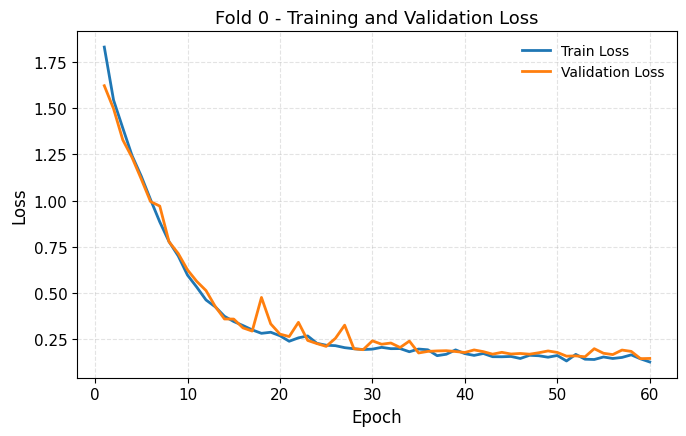

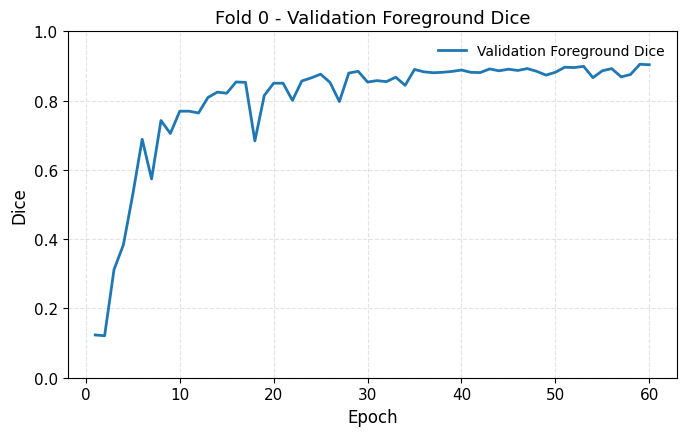

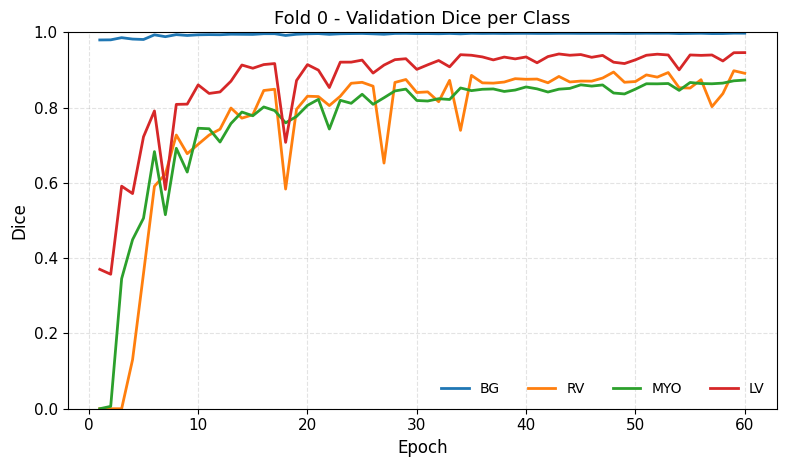

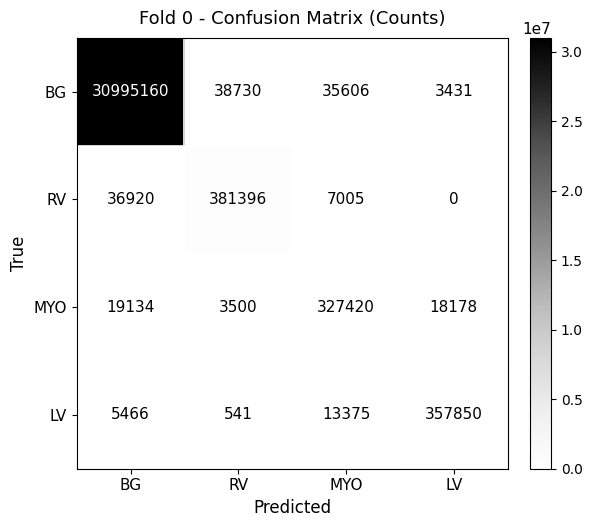

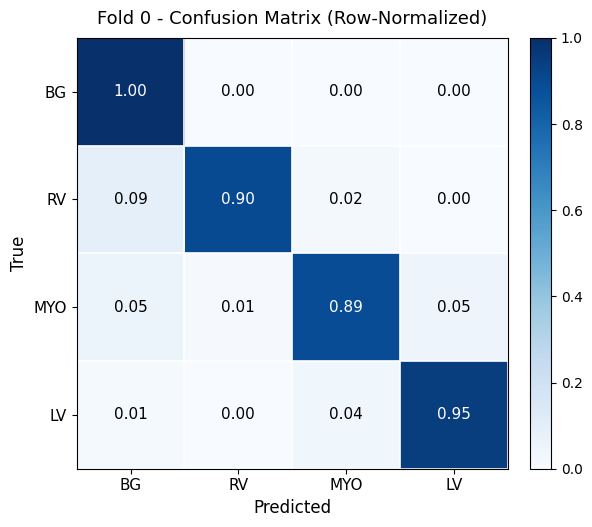


VISUALIZING FOLD 1

Fold 1 best epoch summary
-------------------------------------------------------
Epoch      : 40
Train Loss : 0.1585
Val Loss   : 0.1844
FG Dice    : 0.8778
Dice BG    : 0.9968
Dice RV    : 0.8568
Dice MYO   : 0.8475
Dice LV    : 0.9289


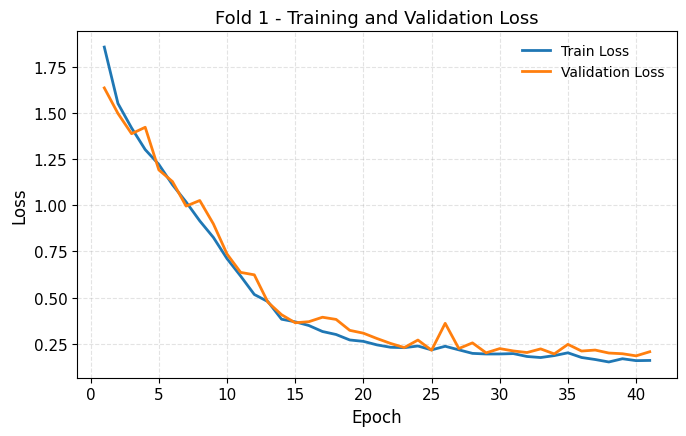

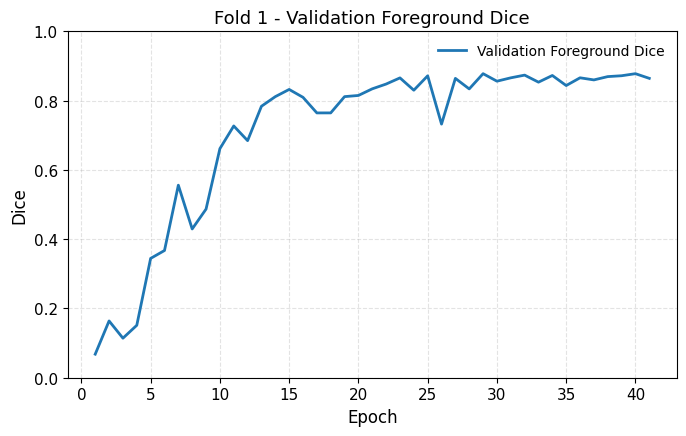

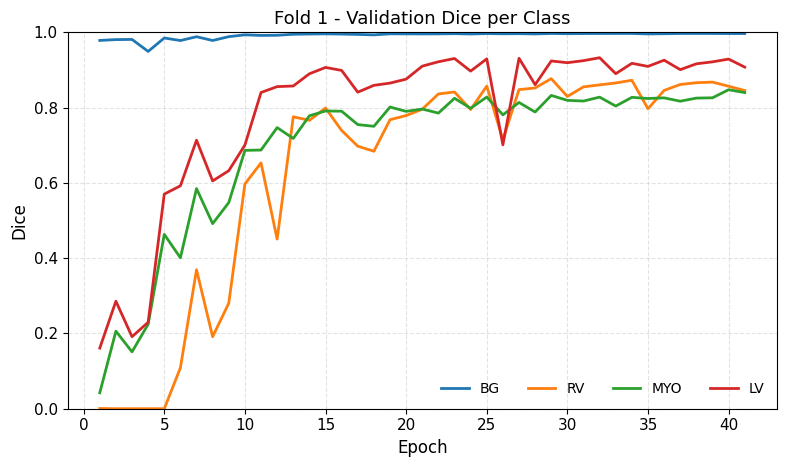

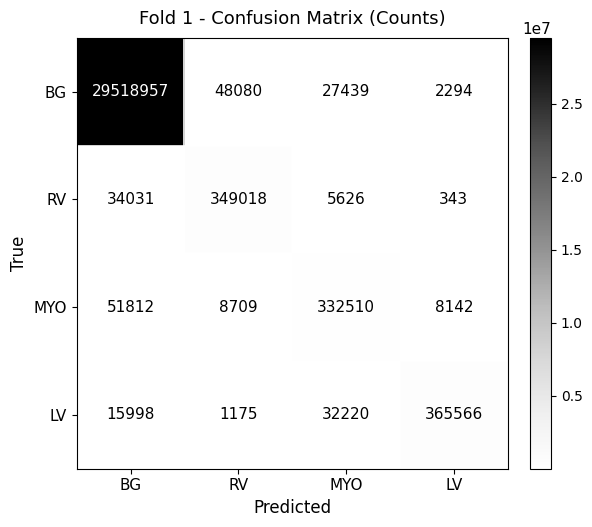

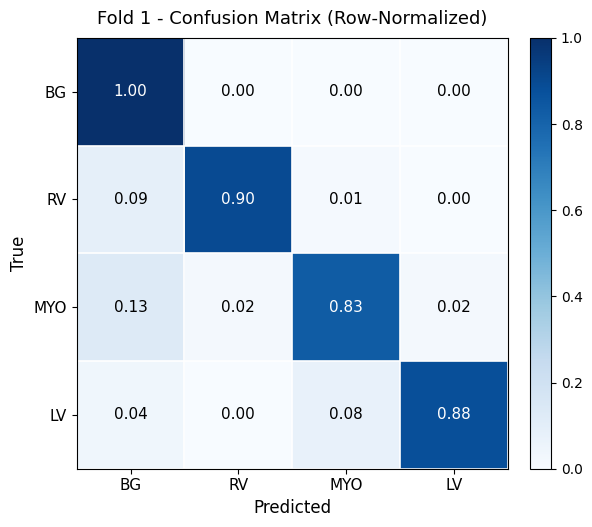


VISUALIZING FOLD 2

Fold 2 best epoch summary
-------------------------------------------------------
Epoch      : 58
Train Loss : 0.1530
Val Loss   : 0.1532
FG Dice    : 0.8994
Dice BG    : 0.9975
Dice RV    : 0.8913
Dice MYO   : 0.8652
Dice LV    : 0.9417


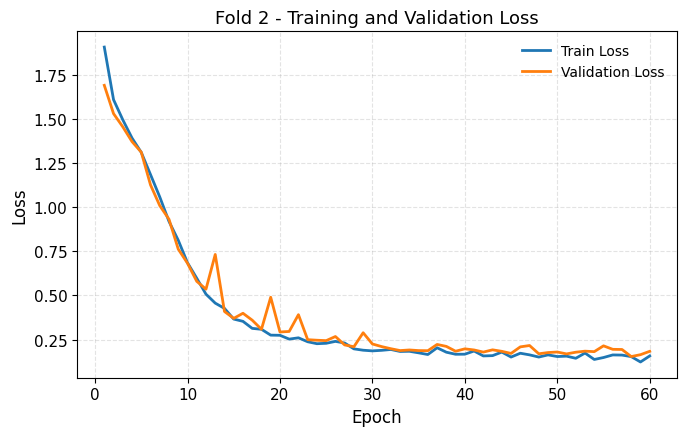

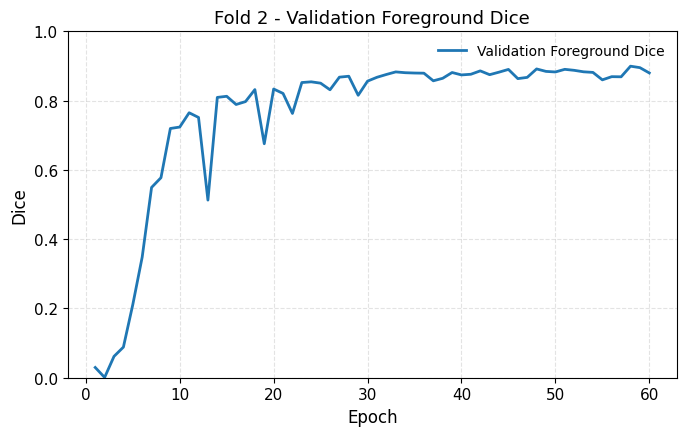

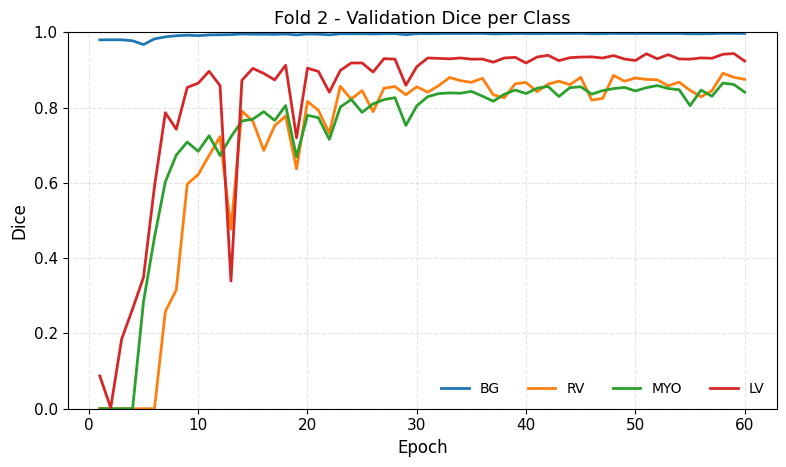

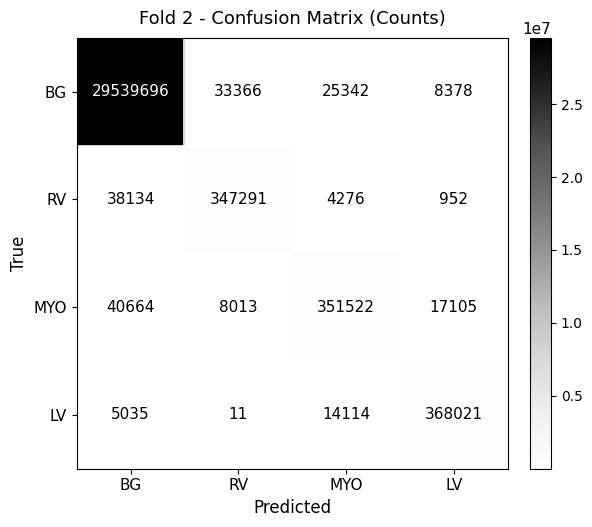

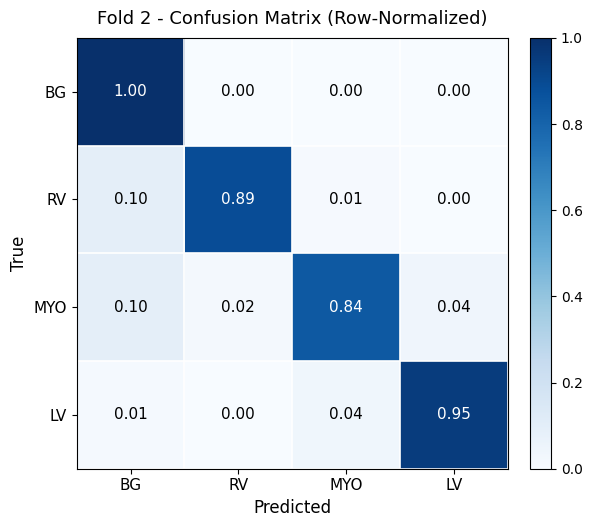


VISUALIZING FOLD 3

Fold 3 best epoch summary
-------------------------------------------------------
Epoch      : 56
Train Loss : 0.1407
Val Loss   : 0.1550
FG Dice    : 0.8934
Dice BG    : 0.9976
Dice RV    : 0.8751
Dice MYO   : 0.8602
Dice LV    : 0.9447


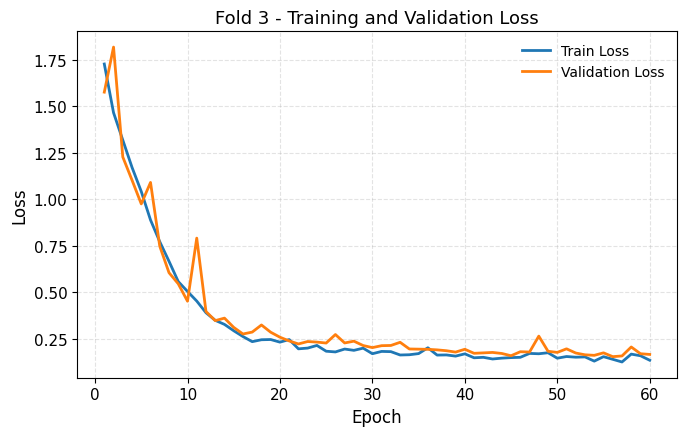

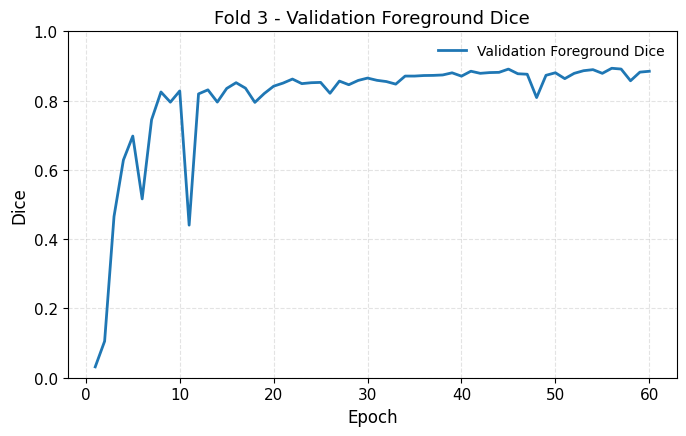

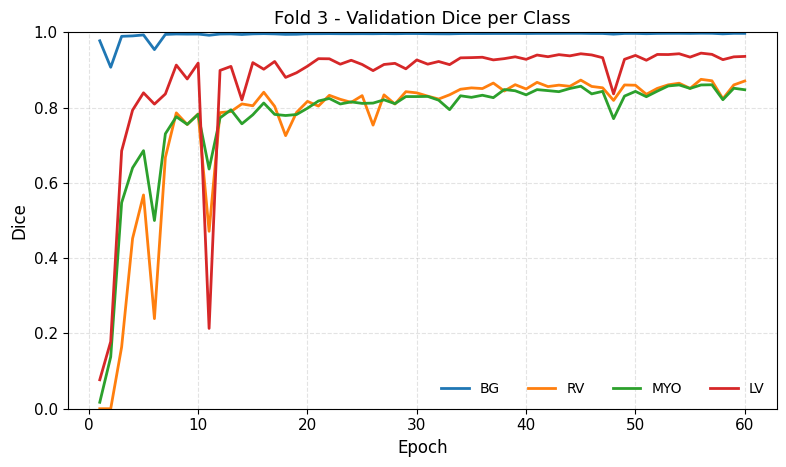

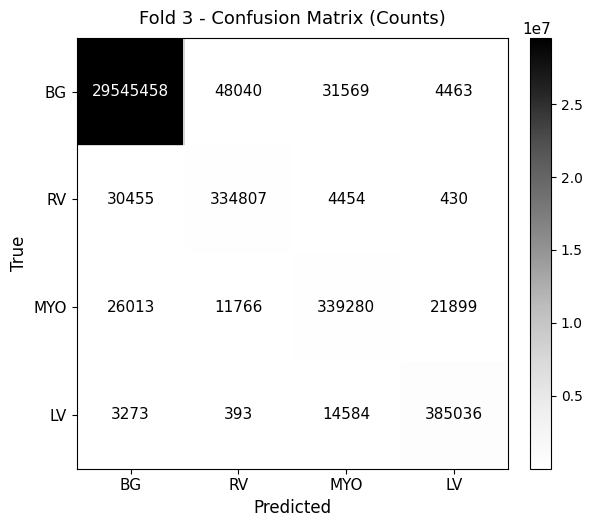

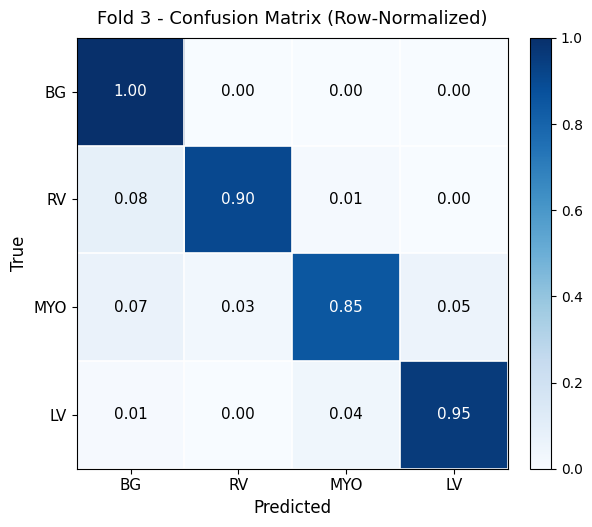

In [ ]:
# ============================================================
# POST-TRAINING VISUALIZATION
# Academic-style plots from saved training history and confusion CSV files
# No retraining
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# CHOOSE EXPERIMENT FOLDER
# Option 1: set manually
# ------------------------------------------------------------
# EXPERIMENT_DIR = Path("./runs_acdc_segmentation_experiments/unet_main_aug_fg_2slice_20260312_223000")

# ------------------------------------------------------------
# Option 2: automatically use latest experiment folder
# ------------------------------------------------------------
RUNS_ROOT = Path("./runs_acdc_segmentation_experiments")
experiment_dirs = sorted([p for p in RUNS_ROOT.iterdir() if p.is_dir()])

if len(experiment_dirs) == 0:
    raise FileNotFoundError(f"No experiment folders found in {RUNS_ROOT.resolve()}")

EXPERIMENT_DIR = experiment_dirs[-1]
print("Using experiment folder:", EXPERIMENT_DIR.resolve())

# ------------------------------------------------------------
# Global style
# ------------------------------------------------------------
CLASS_NAMES = ["BG", "RV", "MYO", "LV"]

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "black",
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
    "font.size": 11
})

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def load_history_csv(path):
    if not path.exists():
        raise FileNotFoundError(path)
    return pd.read_csv(path)

def load_confusion_csv(path):
    if not path.exists():
        raise FileNotFoundError(path)
    df = pd.read_csv(path)
    row_names = df.iloc[:, 0].tolist()
    mat = df.iloc[:, 1:].values.astype(float)
    return row_names, mat

def print_best_epoch_row(history_df, fold_idx):
    best_idx = history_df["val_fg_dice"].idxmax()
    row = history_df.loc[best_idx]

    print(f"\nFold {fold_idx} best epoch summary")
    print("-" * 55)
    print(f"Epoch      : {int(row['epoch'])}")
    print(f"Train Loss : {row['train_loss']:.4f}")
    print(f"Val Loss   : {row['val_loss']:.4f}")
    print(f"FG Dice    : {row['val_fg_dice']:.4f}")
    print(f"Dice BG    : {row['dice_bg']:.4f}")
    print(f"Dice RV    : {row['dice_rv']:.4f}")
    print(f"Dice MYO   : {row['dice_myo']:.4f}")
    print(f"Dice LV    : {row['dice_lv']:.4f}")

def plot_loss_curve(history_df, fold_idx):
    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.plot(history_df["epoch"], history_df["train_loss"], linewidth=2, label="Train Loss")
    ax.plot(history_df["epoch"], history_df["val_loss"], linewidth=2, label="Validation Loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title(f"Fold {fold_idx} - Training and Validation Loss")
    ax.grid(True, linestyle="--", alpha=0.35)
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()

def plot_fg_dice_curve(history_df, fold_idx):
    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.plot(history_df["epoch"], history_df["val_fg_dice"], linewidth=2, label="Validation Foreground Dice")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Dice")
    ax.set_title(f"Fold {fold_idx} - Validation Foreground Dice")
    ax.set_ylim(0, 1.0)
    ax.grid(True, linestyle="--", alpha=0.35)
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()

def plot_class_dice_curve(history_df, fold_idx):
    fig, ax = plt.subplots(figsize=(8, 4.8))
    ax.plot(history_df["epoch"], history_df["dice_bg"], linewidth=2, label="BG")
    ax.plot(history_df["epoch"], history_df["dice_rv"], linewidth=2, label="RV")
    ax.plot(history_df["epoch"], history_df["dice_myo"], linewidth=2, label="MYO")
    ax.plot(history_df["epoch"], history_df["dice_lv"], linewidth=2, label="LV")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Dice")
    ax.set_title(f"Fold {fold_idx} - Validation Dice per Class")
    ax.set_ylim(0, 1.0)
    ax.grid(True, linestyle="--", alpha=0.35)
    ax.legend(frameon=False, ncol=4)
    plt.tight_layout()
    plt.show()

def plot_confusion_matrix_academic(mat, labels, title, fmt=".2f", cmap="Blues", vmin=None, vmax=None):
    mat = np.asarray(mat, dtype=float)

    fig, ax = plt.subplots(figsize=(6.4, 5.4), facecolor="white")
    im = ax.imshow(mat, cmap=cmap, vmin=vmin, vmax=vmax)

    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, fontsize=11)
    ax.set_yticklabels(labels, fontsize=11)

    ax.set_xlabel("Predicted", fontsize=12)
    ax.set_ylabel("True", fontsize=12)
    ax.set_title(title, fontsize=13, pad=10)
    ax.set_aspect("equal")

    ax.set_xticks(np.arange(-0.5, len(labels), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(labels), 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=1.2)
    ax.tick_params(which="minor", bottom=False, left=False)

    threshold = (mat.max() + mat.min()) / 2.0

    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            value = mat[i, j]
            text_color = "white" if value > threshold else "black"
            ax.text(
                j, i, format(value, fmt),
                ha="center", va="center",
                color=text_color, fontsize=11
            )

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=10)

    plt.tight_layout()
    plt.show()

def visualize_one_fold(experiment_dir, fold_idx):
    fold_dir = experiment_dir / f"fold_{fold_idx:02d}"

    history_csv = fold_dir / "history_epoch_metrics.csv"
    cm_counts_csv = fold_dir / "confusion_counts.csv"
    cm_dec_csv = fold_dir / "confusion_row_decimal.csv"

    history_df = load_history_csv(history_csv)
    _, cm_counts = load_confusion_csv(cm_counts_csv)
    _, cm_dec = load_confusion_csv(cm_dec_csv)

    print(f"\n{'=' * 90}")
    print(f"VISUALIZING FOLD {fold_idx}")
    print(f"{'=' * 90}")

    print_best_epoch_row(history_df, fold_idx)

    plot_loss_curve(history_df, fold_idx)
    plot_fg_dice_curve(history_df, fold_idx)
    plot_class_dice_curve(history_df, fold_idx)

    plot_confusion_matrix_academic(
        cm_counts,
        CLASS_NAMES,
        title=f"Fold {fold_idx} - Confusion Matrix (Counts)",
        fmt=".0f",
        cmap="Greys"
    )

    plot_confusion_matrix_academic(
        cm_dec,
        CLASS_NAMES,
        title=f"Fold {fold_idx} - Confusion Matrix (Row-Normalized)",
        fmt=".2f",
        cmap="Blues",
        vmin=0.0,
        vmax=1.0
    )

# ------------------------------------------------------------
# Visualize all folds
# ------------------------------------------------------------
for fold_idx in range(4):
    visualize_one_fold(EXPERIMENT_DIR, fold_idx)

In [ ]:
# ============================================================
# ACDC PAPER-STYLE TEST EVALUATION
# Reports RV / MYO / LV Dice and Mean Dice
# Overall + ED + ES
# ============================================================

import json
from pathlib import Path

import numpy as np
import pandas as pd
import nibabel as nib
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# ------------------------------------------------------------
# REQUIRED MODEL CHECK
# ------------------------------------------------------------
if "UNet" not in globals():
    raise NameError("UNet is not defined. Run the U-Net model cell first.")

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------
ACDC_TEST_DIR = Path(r"c:\Users\manoj\Desktop\Thesis\ACDC\ACDC\database\testing")

# Option 1: choose experiment manually
# EXPERIMENT_DIR = Path(r"./runs_acdc_segmentation_experiments/unet_main_aug_fg_2slice_20260312_180315")

# Option 2: automatically use latest experiment
RUNS_ROOT = Path("./runs_acdc_segmentation_experiments")
if "EXPERIMENT_DIR" not in globals():
    experiment_dirs = sorted([p for p in RUNS_ROOT.iterdir() if p.is_dir()])
    if len(experiment_dirs) == 0:
        raise FileNotFoundError(f"No experiment folders found in {RUNS_ROOT.resolve()}")
    EXPERIMENT_DIR = experiment_dirs[-1]

print("Using experiment folder:", EXPERIMENT_DIR.resolve())

# ------------------------------------------------------------
# LOAD CONFIG
# ------------------------------------------------------------
config_path = EXPERIMENT_DIR / "experiment_config.json"
if config_path.exists():
    with open(config_path, "r", encoding="utf-8") as f:
        exp_cfg = json.load(f)
    TEST_IMG_SIZE = int(exp_cfg.get("img_size", 256))
    N_CLASSES = int(exp_cfg.get("n_classes", 4))
    CLASS_NAMES = exp_cfg.get("class_names", ["BG", "RV", "MYO", "LV"])
else:
    TEST_IMG_SIZE = 256
    N_CLASSES = 4
    CLASS_NAMES = ["BG", "RV", "MYO", "LV"]

TEST_BATCH_SIZE = 8
TEST_NUM_WORKERS = 0

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("Test image size:", TEST_IMG_SIZE)
print("Classes:", CLASS_NAMES)

TEST_OUT_DIR = EXPERIMENT_DIR / "test_evaluation_paper_style"
TEST_OUT_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------
def read_ed_es(info_cfg_path: Path):
    ed = None
    es = None
    for line in info_cfg_path.read_text().splitlines():
        line = line.strip()
        if line.startswith("ED:"):
            ed = int(line.split(":")[1].strip())
        elif line.startswith("ES:"):
            es = int(line.split(":")[1].strip())
    if ed is None or es is None:
        raise ValueError(f"Missing ED/ES in {info_cfg_path}")
    return ed, es

def zscore(x: np.ndarray) -> np.ndarray:
    x = x.astype(np.float32)
    return (x - x.mean()) / (x.std() + 1e-8)

def get_ed_es_paths(patient_dir: Path):
    pid = patient_dir.name
    info = patient_dir / "Info.cfg"
    if not info.exists():
        raise FileNotFoundError(info)

    ed, es = read_ed_es(info)

    ed_img = patient_dir / f"{pid}_frame{ed:02d}.nii.gz"
    ed_msk = patient_dir / f"{pid}_frame{ed:02d}_gt.nii.gz"
    es_img = patient_dir / f"{pid}_frame{es:02d}.nii.gz"
    es_msk = patient_dir / f"{pid}_frame{es:02d}_gt.nii.gz"

    for p in (ed_img, ed_msk, es_img, es_msk):
        if not p.exists():
            raise FileNotFoundError(p)

    return ed_img, ed_msk, es_img, es_msk

def resize_img_mask(img_2d: np.ndarray, msk_2d: np.ndarray, img_size: int):
    img = torch.from_numpy(img_2d).float().unsqueeze(0).unsqueeze(0)
    msk = torch.from_numpy(msk_2d.astype(np.int64)).unsqueeze(0).unsqueeze(0).float()

    img = F.interpolate(img, size=(img_size, img_size), mode="bilinear", align_corners=False)
    msk = F.interpolate(msk, size=(img_size, img_size), mode="nearest")

    img = img.squeeze(0)
    msk = msk.squeeze(0).squeeze(0).long()
    return img, msk

def compute_confusion_matrix(true_flat: np.ndarray, pred_flat: np.ndarray, n_classes: int) -> np.ndarray:
    true_flat = true_flat.astype(np.int64)
    pred_flat = pred_flat.astype(np.int64)
    k = true_flat * n_classes + pred_flat
    binc = np.bincount(k, minlength=n_classes * n_classes)
    return binc.reshape(n_classes, n_classes)

def dice_per_class_from_cm(cm: np.ndarray, eps: float = 1e-6):
    dice = np.zeros(cm.shape[0], dtype=np.float32)
    for c in range(cm.shape[0]):
        tp = cm[c, c]
        fp = cm[:, c].sum() - tp
        fn = cm[c, :].sum() - tp
        dice[c] = (2 * tp + eps) / (2 * tp + fp + fn + eps)
    return dice

def paper_metrics_from_cm(cm: np.ndarray):
    dice = dice_per_class_from_cm(cm)
    rv = float(dice[1])
    myo = float(dice[2])
    lv = float(dice[3])
    mean_dice = float(np.mean([rv, myo, lv]))
    return {
        "rv_dice": rv,
        "myo_dice": myo,
        "lv_dice": lv,
        "mean_dice": mean_dice
    }

def mean_std(x):
    x = np.array(x, dtype=np.float64)
    mean = float(np.mean(x))
    std = float(np.std(x, ddof=1)) if len(x) > 1 else 0.0
    return mean, std

def save_paper_table_txt(path, title, metrics_dict):
    lines = [
        title,
        "-" * len(title),
        f"RV Dice   : {metrics_dict['rv_dice']:.4f}",
        f"MYO Dice  : {metrics_dict['myo_dice']:.4f}",
        f"LV Dice   : {metrics_dict['lv_dice']:.4f}",
        f"Mean Dice : {metrics_dict['mean_dice']:.4f}",
    ]
    path.write_text("\n".join(lines), encoding="utf-8")

# ------------------------------------------------------------
# TEST DATASET
# ------------------------------------------------------------
class ACDCTestAllSlices(Dataset):
    def __init__(self, patient_dirs, img_size=256, phase="both", cache=True):
        self.patient_dirs = list(patient_dirs)
        self.img_size = img_size
        self.phase = phase.lower()
        self.cache = {} if cache else None
        self.index = []

        for pd in self.patient_dirs:
            ed_img, ed_msk, es_img, es_msk = get_ed_es_paths(pd)
            ed_vol = nib.load(str(ed_img)).get_fdata()
            S = ed_vol.shape[2]

            if self.phase in ("ed", "both"):
                for s in range(S):
                    self.index.append((pd, "ED", s))

            if self.phase in ("es", "both"):
                for s in range(S):
                    self.index.append((pd, "ES", s))

    def __len__(self):
        return len(self.index)

    def _load_patient(self, pd: Path):
        pid = pd.name
        if self.cache is not None and pid in self.cache:
            return self.cache[pid]

        ed_img, ed_msk, es_img, es_msk = get_ed_es_paths(pd)
        ed_vol = nib.load(str(ed_img)).get_fdata()
        ed_gt  = nib.load(str(ed_msk)).get_fdata()
        es_vol = nib.load(str(es_img)).get_fdata()
        es_gt  = nib.load(str(es_msk)).get_fdata()

        data = (ed_vol, ed_gt, es_vol, es_gt)
        if self.cache is not None:
            self.cache[pid] = data
        return data

    def __getitem__(self, idx):
        pd, phase, s = self.index[idx]
        pid = pd.name

        ed_vol, ed_gt, es_vol, es_gt = self._load_patient(pd)

        if phase == "ED":
            img2d = zscore(ed_vol[:, :, s])
            msk2d = np.clip(ed_gt[:, :, s].astype(np.int64), 0, N_CLASSES - 1)
        else:
            img2d = zscore(es_vol[:, :, s])
            msk2d = np.clip(es_gt[:, :, s].astype(np.int64), 0, N_CLASSES - 1)

        img, mask = resize_img_mask(img2d, msk2d, self.img_size)

        return {
            "image": img,
            "mask": mask,
            "meta": {
                "patient": pid,
                "phase": phase,
                "slice": int(s)
            }
        }

# ------------------------------------------------------------
# BUILD TEST LOADER
# ------------------------------------------------------------
test_patients = sorted([p for p in ACDC_TEST_DIR.iterdir() if p.is_dir() and p.name.startswith("patient")])
if len(test_patients) == 0:
    raise FileNotFoundError(f"No patient folders found in {ACDC_TEST_DIR.resolve()}")

test_dataset = ACDCTestAllSlices(
    test_patients,
    img_size=TEST_IMG_SIZE,
    phase="both",
    cache=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=TEST_BATCH_SIZE,
    shuffle=False,
    num_workers=TEST_NUM_WORKERS,
    drop_last=False
)

print(f"Test patients: {len(test_patients)}")
print(f"Test samples : {len(test_dataset)}")
print(f"Test batches : {len(test_loader)}")

# ------------------------------------------------------------
# EVALUATION
# ------------------------------------------------------------
@torch.no_grad()
def evaluate_checkpoint_paper_style(model, loader):
    model.eval()

    cm_all = np.zeros((N_CLASSES, N_CLASSES), dtype=np.int64)
    cm_ed  = np.zeros((N_CLASSES, N_CLASSES), dtype=np.int64)
    cm_es  = np.zeros((N_CLASSES, N_CLASSES), dtype=np.int64)

    for batch in loader:
        images = batch["image"].to(device, dtype=torch.float32)
        masks = batch["mask"].to(device, dtype=torch.long)
        phases = batch["meta"]["phase"]

        logits = model(images)
        pred = torch.argmax(logits, dim=1).cpu().numpy()
        true = masks.cpu().numpy()

        for i in range(len(phases)):
            cm_i = compute_confusion_matrix(
                true[i].reshape(-1),
                pred[i].reshape(-1),
                N_CLASSES
            )
            cm_all += cm_i

            if phases[i] == "ED":
                cm_ed += cm_i
            elif phases[i] == "ES":
                cm_es += cm_i

    metrics_all = paper_metrics_from_cm(cm_all)
    metrics_ed = paper_metrics_from_cm(cm_ed)
    metrics_es = paper_metrics_from_cm(cm_es)

    return {
        "cm_all": cm_all,
        "cm_ed": cm_ed,
        "cm_es": cm_es,
        "metrics_all": metrics_all,
        "metrics_ed": metrics_ed,
        "metrics_es": metrics_es
    }

# ------------------------------------------------------------
# RUN TEST EVALUATION FOR ALL 4 FOLDS
# ------------------------------------------------------------
all_fold_rows = []

for fold_idx in range(4):
    print("\n" + "=" * 90)
    print(f"TEST EVALUATION - FOLD {fold_idx}")
    print("=" * 90)

    fold_dir = EXPERIMENT_DIR / f"fold_{fold_idx:02d}"
    if not fold_dir.exists():
        raise FileNotFoundError(f"Fold folder missing: {fold_dir}")

    ckpt_candidates = sorted(fold_dir.glob(f"*_best_fold{fold_idx}.pth"))
    if len(ckpt_candidates) == 0:
        raise FileNotFoundError(f"No best checkpoint found in {fold_dir}")

    ckpt_path = ckpt_candidates[0]
    print("Checkpoint:", ckpt_path.name)

    ckpt = torch.load(ckpt_path, map_location=device)

    model = UNet(in_channels=1, out_channels=N_CLASSES, bilinear=False).to(device)
    model.load_state_dict(ckpt["model_state"])

    results = evaluate_checkpoint_paper_style(model, test_loader)

    fold_out_dir = TEST_OUT_DIR / f"fold_{fold_idx:02d}"
    fold_out_dir.mkdir(parents=True, exist_ok=True)

    metrics_all = results["metrics_all"]
    metrics_ed = results["metrics_ed"]
    metrics_es = results["metrics_es"]

    save_paper_table_txt(
        fold_out_dir / "overall_paper_style_results.txt",
        f"Fold {fold_idx} Overall Test Results",
        metrics_all
    )
    save_paper_table_txt(
        fold_out_dir / "ed_paper_style_results.txt",
        f"Fold {fold_idx} ED Test Results",
        metrics_ed
    )
    save_paper_table_txt(
        fold_out_dir / "es_paper_style_results.txt",
        f"Fold {fold_idx} ES Test Results",
        metrics_es
    )

    print("Overall")
    print(f"  RV Dice   : {metrics_all['rv_dice']:.4f}")
    print(f"  MYO Dice  : {metrics_all['myo_dice']:.4f}")
    print(f"  LV Dice   : {metrics_all['lv_dice']:.4f}")
    print(f"  Mean Dice : {metrics_all['mean_dice']:.4f}")

    print("ED")
    print(f"  RV Dice   : {metrics_ed['rv_dice']:.4f}")
    print(f"  MYO Dice  : {metrics_ed['myo_dice']:.4f}")
    print(f"  LV Dice   : {metrics_ed['lv_dice']:.4f}")
    print(f"  Mean Dice : {metrics_ed['mean_dice']:.4f}")

    print("ES")
    print(f"  RV Dice   : {metrics_es['rv_dice']:.4f}")
    print(f"  MYO Dice  : {metrics_es['myo_dice']:.4f}")
    print(f"  LV Dice   : {metrics_es['lv_dice']:.4f}")
    print(f"  Mean Dice : {metrics_es['mean_dice']:.4f}")

    all_fold_rows.append({
        "fold": fold_idx,
        "checkpoint": str(ckpt_path),

        "overall_rv_dice": metrics_all["rv_dice"],
        "overall_myo_dice": metrics_all["myo_dice"],
        "overall_lv_dice": metrics_all["lv_dice"],
        "overall_mean_dice": metrics_all["mean_dice"],

        "ed_rv_dice": metrics_ed["rv_dice"],
        "ed_myo_dice": metrics_ed["myo_dice"],
        "ed_lv_dice": metrics_ed["lv_dice"],
        "ed_mean_dice": metrics_ed["mean_dice"],

        "es_rv_dice": metrics_es["rv_dice"],
        "es_myo_dice": metrics_es["myo_dice"],
        "es_lv_dice": metrics_es["lv_dice"],
        "es_mean_dice": metrics_es["mean_dice"],
    })

# ------------------------------------------------------------
# SAVE PER-FOLD CSV
# ------------------------------------------------------------
df_folds = pd.DataFrame(all_fold_rows)
per_fold_csv = TEST_OUT_DIR / "paper_style_test_results_per_fold.csv"
df_folds.to_csv(per_fold_csv, index=False)

# ------------------------------------------------------------
# FINAL MEAN ± STD SUMMARY
# ------------------------------------------------------------
def summarize_metric(df, col):
    return mean_std(df[col].values)

summary_lines = []
summary_lines.append("ACDC PAPER-STYLE TEST RESULTS")
summary_lines.append("=" * 40)

sections = [
    ("Overall", "overall"),
    ("ED", "ed"),
    ("ES", "es"),
]

for section_name, prefix in sections:
    rv_m, rv_s = summarize_metric(df_folds, f"{prefix}_rv_dice")
    myo_m, myo_s = summarize_metric(df_folds, f"{prefix}_myo_dice")
    lv_m, lv_s = summarize_metric(df_folds, f"{prefix}_lv_dice")
    mean_m, mean_s = summarize_metric(df_folds, f"{prefix}_mean_dice")

    summary_lines.append(f"\n{section_name}")
    summary_lines.append(f"RV Dice   : {rv_m:.4f} ± {rv_s:.4f}")
    summary_lines.append(f"MYO Dice  : {myo_m:.4f} ± {myo_s:.4f}")
    summary_lines.append(f"LV Dice   : {lv_m:.4f} ± {lv_s:.4f}")
    summary_lines.append(f"Mean Dice : {mean_m:.4f} ± {mean_s:.4f}")

summary_txt = TEST_OUT_DIR / "Final_test_results_mean_std.txt"
summary_txt.write_text("\n".join(summary_lines), encoding="utf-8")

print("\n" + "=" * 90)
print("FINAL TEST SUMMARY")
print("=" * 90)
print(summary_txt.read_text(encoding="utf-8"))

print("\nSaved files:")
print(per_fold_csv)
print(summary_txt)
print("\nDone.")

Using experiment folder: C:\Users\manoj\Desktop\Thesis\16873796\runs_acdc_segmentation_experiments\unet_main_aug_fg_2slice_20260312_180315
Device: cuda
Test image size: 256
Classes: ['BG', 'RV', 'MYO', 'LV']
Test patients: 50
Test samples : 1076
Test batches : 135

TEST EVALUATION - FOLD 0
Checkpoint: unet_main_aug_fg_2slice_best_fold0.pth
Overall
  RV Dice   : 0.8838
  MYO Dice  : 0.8605
  LV Dice   : 0.9438
  Mean Dice : 0.8960
ED
  RV Dice   : 0.9054
  MYO Dice  : 0.8568
  LV Dice   : 0.9548
  Mean Dice : 0.9057
ES
  RV Dice   : 0.8466
  MYO Dice  : 0.8639
  LV Dice   : 0.9233
  Mean Dice : 0.8779

TEST EVALUATION - FOLD 1
Checkpoint: unet_main_aug_fg_2slice_best_fold1.pth
Overall
  RV Dice   : 0.8840
  MYO Dice  : 0.8113
  LV Dice   : 0.9099
  Mean Dice : 0.8684
ED
  RV Dice   : 0.9046
  MYO Dice  : 0.8171
  LV Dice   : 0.9251
  Mean Dice : 0.8822
ES
  RV Dice   : 0.8490
  MYO Dice  : 0.8056
  LV Dice   : 0.8804
  Mean Dice : 0.8450

TEST EVALUATION - FOLD 2
Checkpoint: unet_main_a

Using experiment folder: C:\Users\manoj\Desktop\Thesis\16873796\runs_acdc_segmentation_experiments\unet_main_aug_fg_2slice_20260312_180315
Saving thesis figures to: C:\Users\manoj\Desktop\Thesis\16873796\runs_acdc_segmentation_experiments\unet_main_aug_fg_2slice_20260312_180315\thesis_visualizations

VISUALIZING FOLD 0

Fold 0 best epoch summary
-------------------------------------------------------
Epoch      : 59
Train Loss : 0.1431
Val Loss   : 0.1440
FG Dice    : 0.9050
Dice BG    : 0.9978
Dice RV    : 0.8979
Dice MYO   : 0.8712
Dice LV    : 0.9458


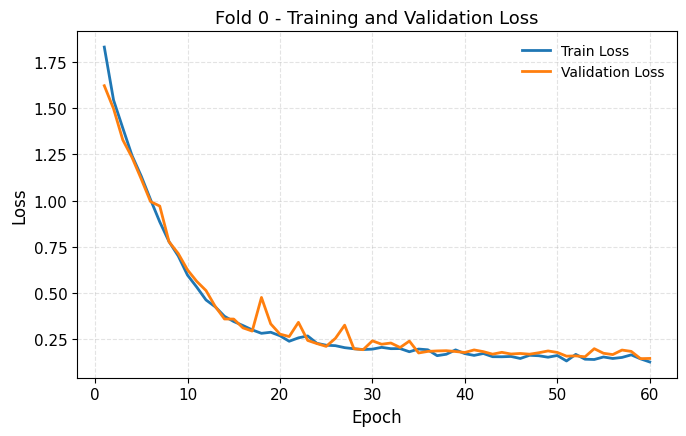

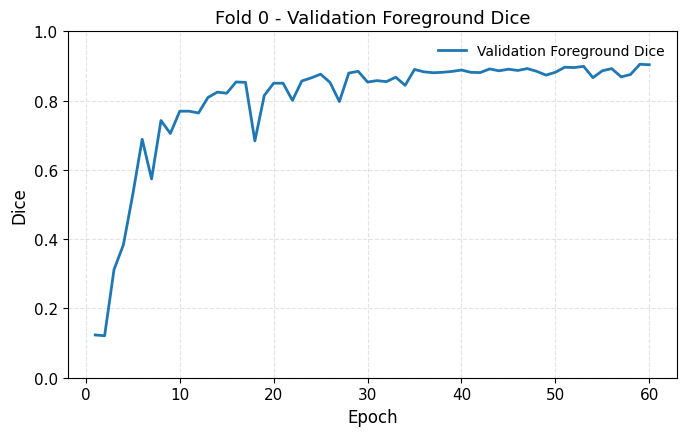

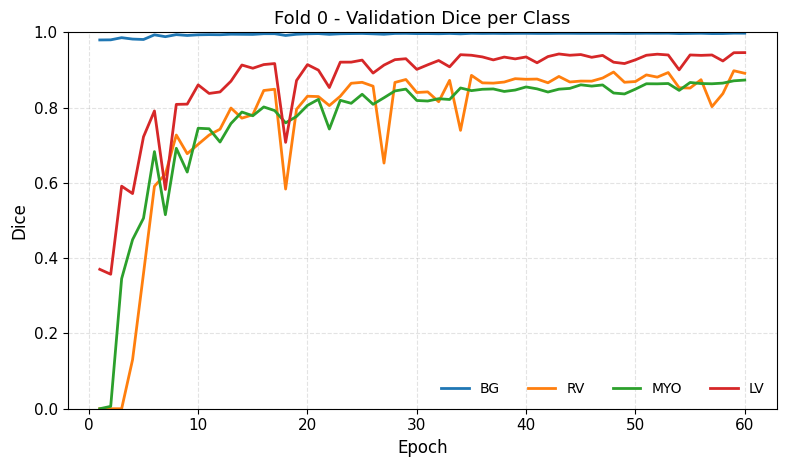

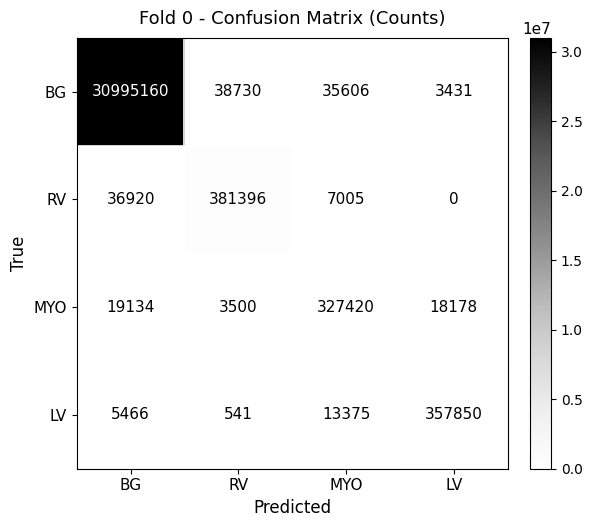

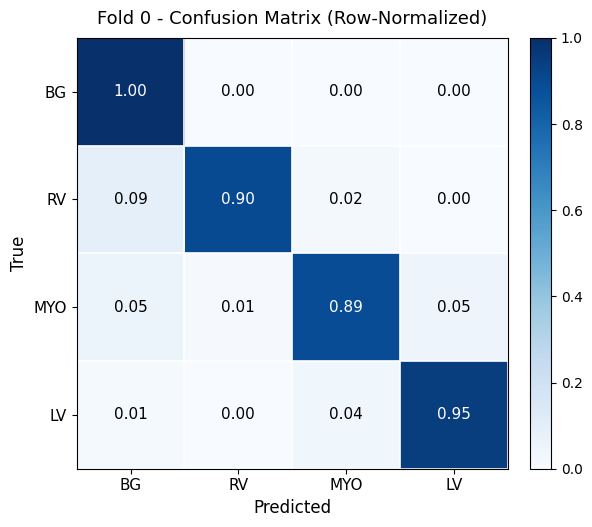


VISUALIZING FOLD 1

Fold 1 best epoch summary
-------------------------------------------------------
Epoch      : 40
Train Loss : 0.1585
Val Loss   : 0.1844
FG Dice    : 0.8778
Dice BG    : 0.9968
Dice RV    : 0.8568
Dice MYO   : 0.8475
Dice LV    : 0.9289


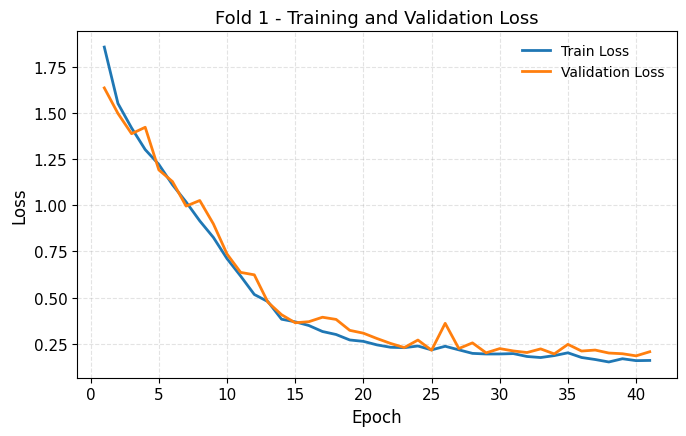

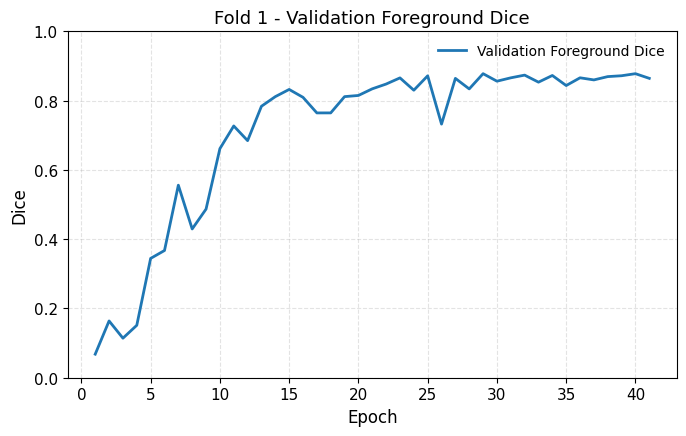

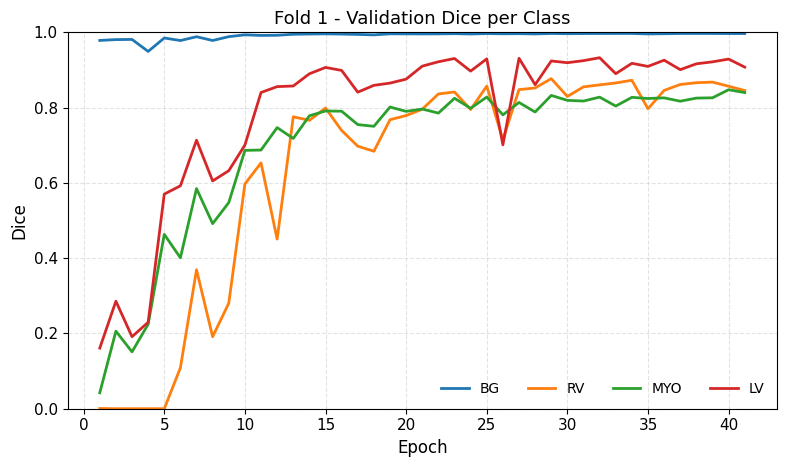

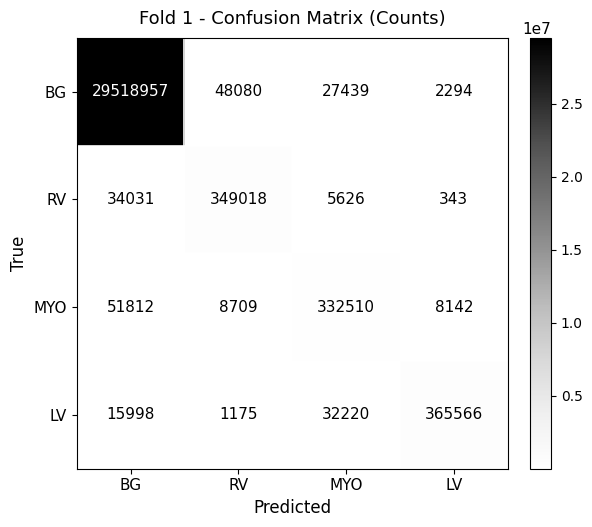

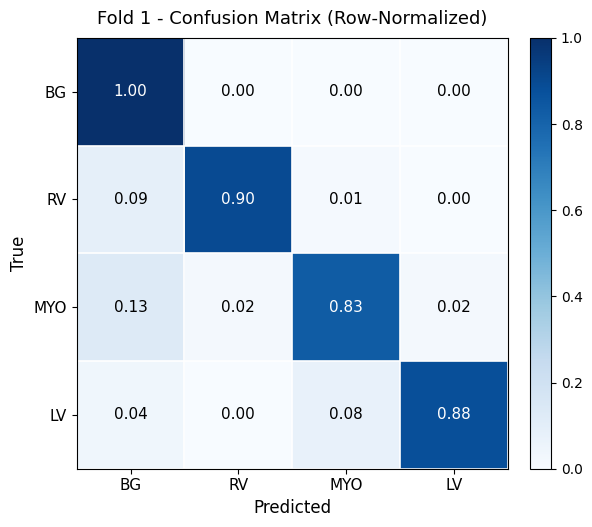


VISUALIZING FOLD 2

Fold 2 best epoch summary
-------------------------------------------------------
Epoch      : 58
Train Loss : 0.1530
Val Loss   : 0.1532
FG Dice    : 0.8994
Dice BG    : 0.9975
Dice RV    : 0.8913
Dice MYO   : 0.8652
Dice LV    : 0.9417


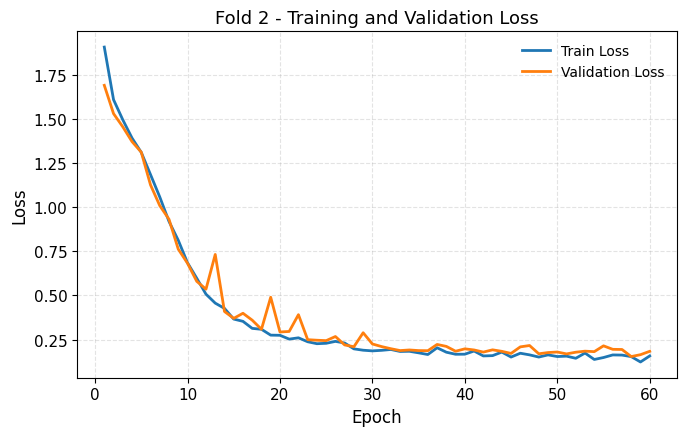

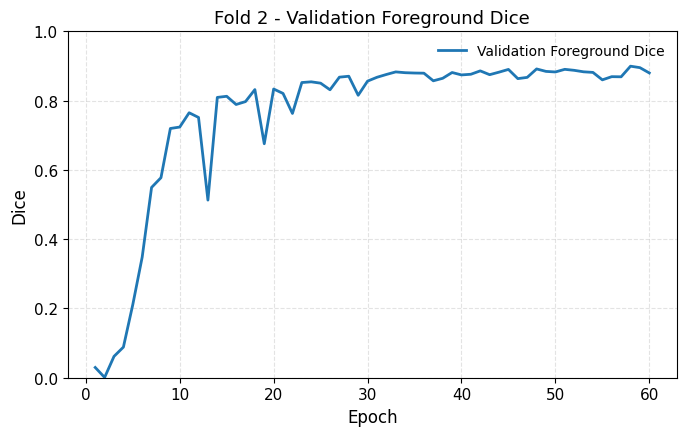

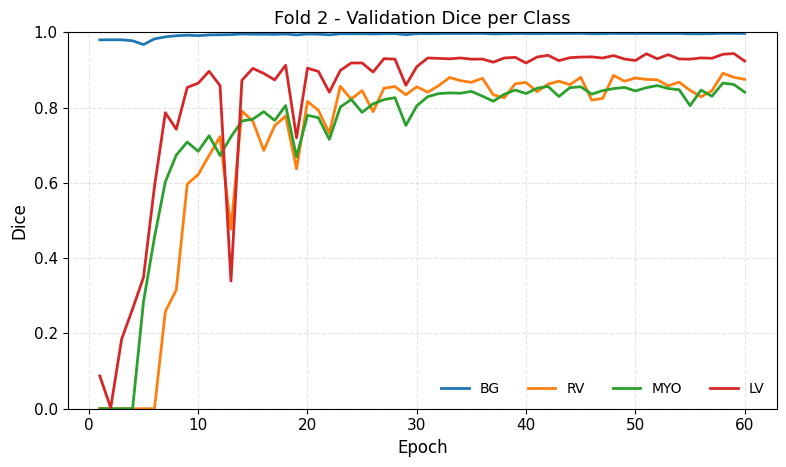

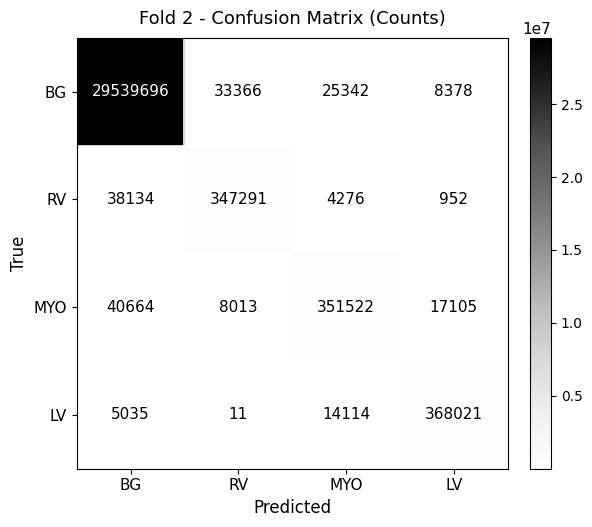

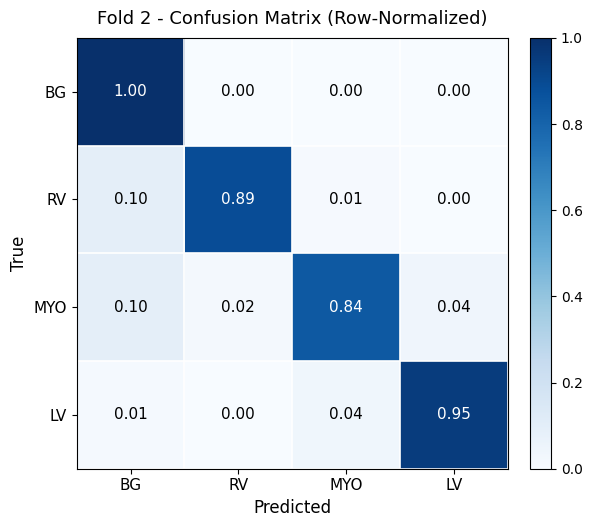


VISUALIZING FOLD 3

Fold 3 best epoch summary
-------------------------------------------------------
Epoch      : 56
Train Loss : 0.1407
Val Loss   : 0.1550
FG Dice    : 0.8934
Dice BG    : 0.9976
Dice RV    : 0.8751
Dice MYO   : 0.8602
Dice LV    : 0.9447


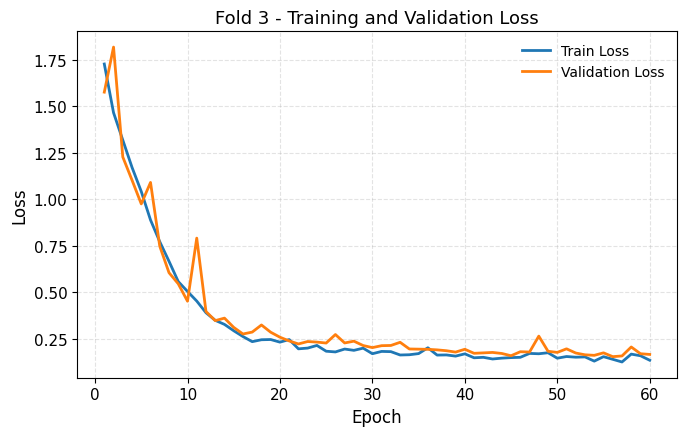

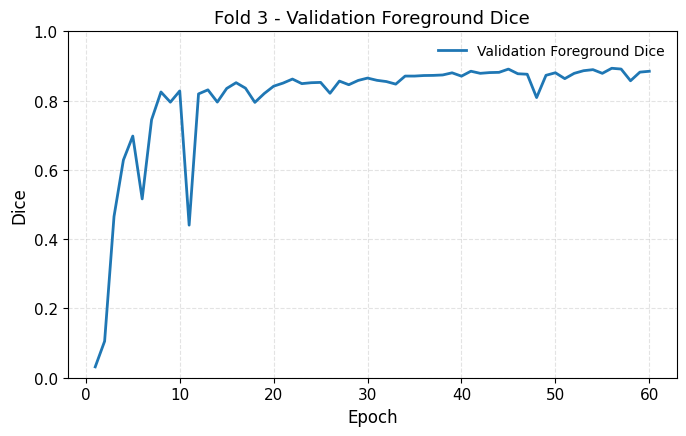

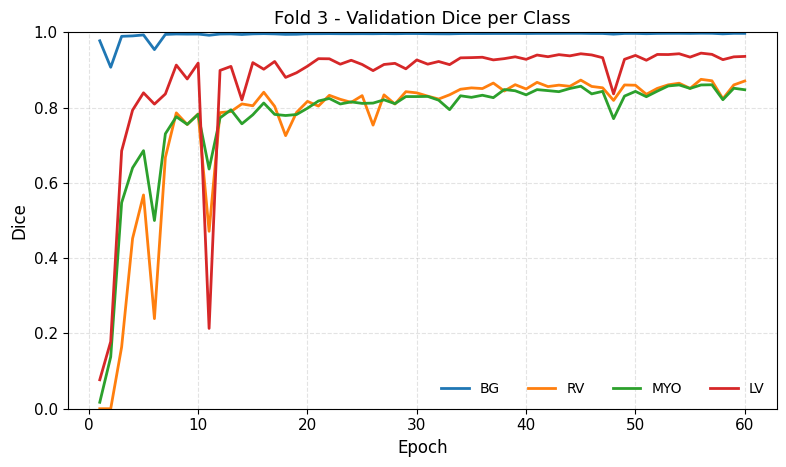

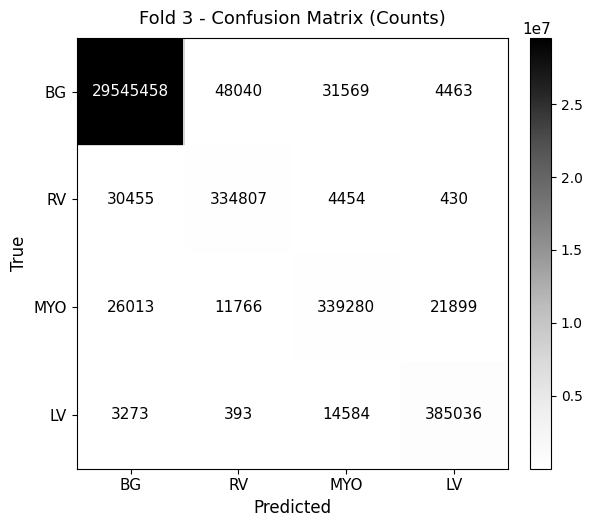

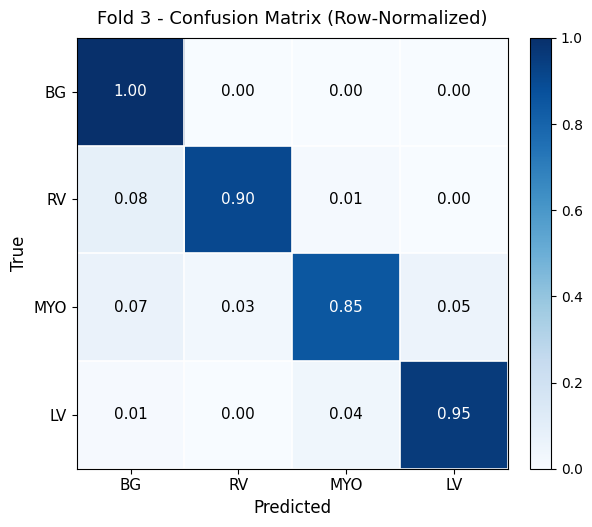


Cross-fold validation table
   fold  best_epoch  val_loss   dice_bg   dice_rv  dice_myo   dice_lv  \
0     0          59  0.143990  0.997758  0.897943  0.871217  0.945829   
1     1          29  0.200761  0.996966  0.876930  0.832349  0.923958   
2     2          58  0.153217  0.997452  0.891251  0.865223  0.941667   
3     3          56  0.155048  0.997572  0.875139  0.860194  0.944741   

    fg_dice                                    best_checkpoint  \
0  0.904996  runs_acdc_segmentation_experiments\unet_main_a...   
1  0.877746  runs_acdc_segmentation_experiments\unet_main_a...   
2  0.899380  runs_acdc_segmentation_experiments\unet_main_a...   
3  0.893358  runs_acdc_segmentation_experiments\unet_main_a...   

                                     last_checkpoint  
0  runs_acdc_segmentation_experiments\unet_main_a...  
1  runs_acdc_segmentation_experiments\unet_main_a...  
2  runs_acdc_segmentation_experiments\unet_main_a...  
3  runs_acdc_segmentation_experiments\unet_main_a...  

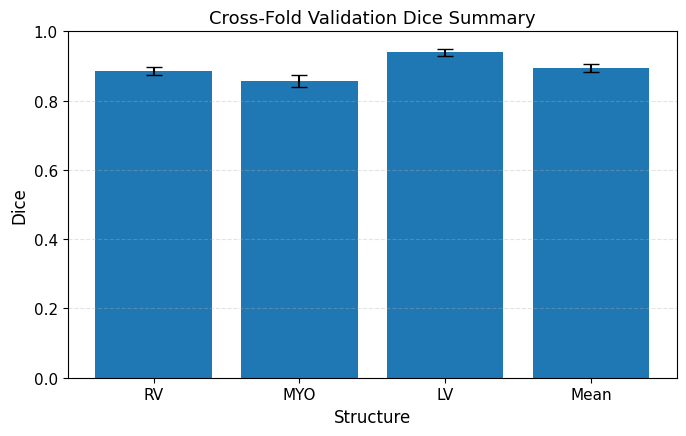


Paper-style test results table
   fold                                         checkpoint  overall_rv_dice  \
0     0  runs_acdc_segmentation_experiments\unet_main_a...         0.883793   
1     1  runs_acdc_segmentation_experiments\unet_main_a...         0.884048   
2     2  runs_acdc_segmentation_experiments\unet_main_a...         0.888902   
3     3  runs_acdc_segmentation_experiments\unet_main_a...         0.894256   

   overall_myo_dice  overall_lv_dice  overall_mean_dice  ed_rv_dice  \
0          0.860451         0.943846           0.896030    0.905383   
1          0.811265         0.909898           0.868404    0.904568   
2          0.852695         0.938769           0.893455    0.911852   
3          0.856175         0.944578           0.898336    0.913587   

   ed_myo_dice  ed_lv_dice  ed_mean_dice  es_rv_dice  es_myo_dice  es_lv_dice  \
0     0.856798    0.954804      0.905662    0.846599     0.863875    0.923298   
1     0.817056    0.925119      0.882247    0.848973  

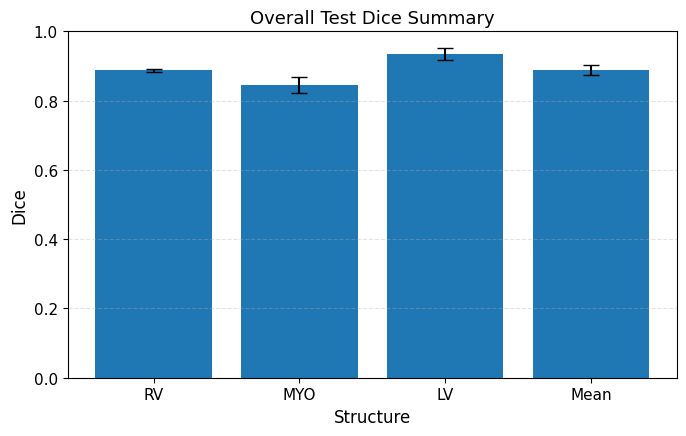

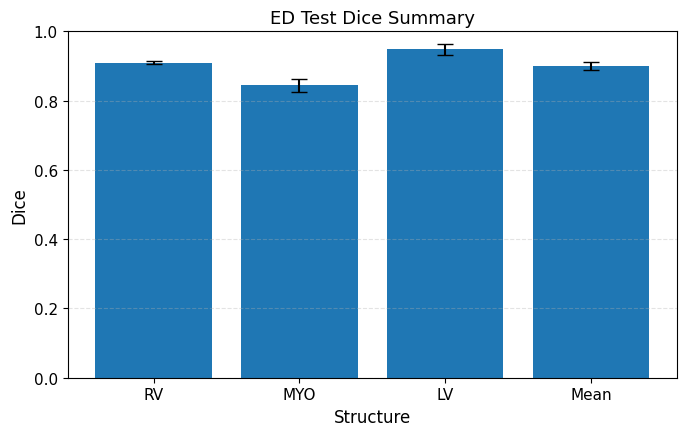

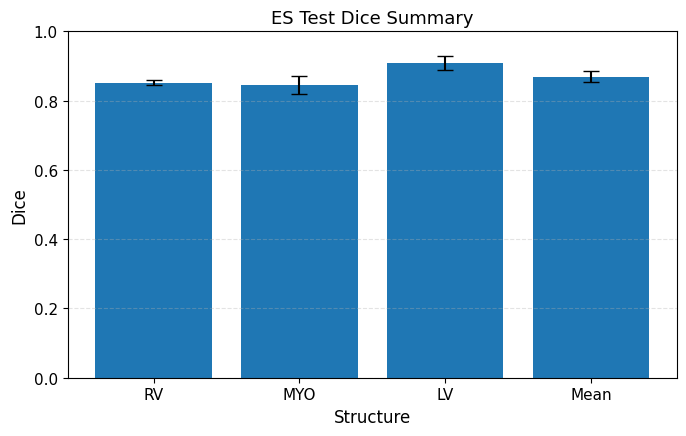


All thesis visualizations are generated and saved.
Folder: C:\Users\manoj\Desktop\Thesis\16873796\runs_acdc_segmentation_experiments\unet_main_aug_fg_2slice_20260312_180315\thesis_visualizations


In [ ]:
# ============================================================
# COMPLETE  VISUALIZATION SETUP
# Reads saved training + validation + test files
# No retraining
# Saves thesis-ready PNG and PDF figures
# ============================================================

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# CHOOSE EXPERIMENT FOLDER
# Option 1: set manually
# ------------------------------------------------------------
# EXPERIMENT_DIR = Path(r"./runs_acdc_segmentation_experiments/unet_main_aug_fg_2slice_20260312_180315")

# ------------------------------------------------------------
# Option 2: automatically use latest experiment
# ------------------------------------------------------------
RUNS_ROOT = Path("./runs_acdc_segmentation_experiments")
experiment_dirs = sorted([p for p in RUNS_ROOT.iterdir() if p.is_dir()])
if len(experiment_dirs) == 0:
    raise FileNotFoundError(f"No experiment folders found in {RUNS_ROOT.resolve()}")

EXPERIMENT_DIR = experiment_dirs[-1]
print("Using experiment folder:", EXPERIMENT_DIR.resolve())

# ------------------------------------------------------------
# OUTPUT FOLDER FOR THESIS FIGURES
# ------------------------------------------------------------
THESIS_FIG_DIR = EXPERIMENT_DIR / "thesis_visualizations"
THESIS_FIG_DIR.mkdir(parents=True, exist_ok=True)
print("Saving thesis figures to:", THESIS_FIG_DIR.resolve())

# ------------------------------------------------------------
# STYLE
# ------------------------------------------------------------
CLASS_NAMES = ["BG", "RV", "MYO", "LV"]

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "black",
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
    "font.size": 11
})

# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------
def load_history_csv(path):
    if not path.exists():
        raise FileNotFoundError(path)
    return pd.read_csv(path)

def load_confusion_csv(path):
    if not path.exists():
        raise FileNotFoundError(path)
    df = pd.read_csv(path)
    row_names = df.iloc[:, 0].tolist()
    mat = df.iloc[:, 1:].values.astype(float)
    return row_names, mat

def save_fig_both(fig, png_path, pdf_path):
    fig.savefig(png_path, dpi=300, bbox_inches="tight", facecolor="white")
    fig.savefig(pdf_path, bbox_inches="tight", facecolor="white")

def mean_std(x):
    x = np.array(x, dtype=np.float64)
    mean = float(np.mean(x))
    std = float(np.std(x, ddof=1)) if len(x) > 1 else 0.0
    return mean, std

def print_best_epoch_row(history_df, fold_idx):
    best_idx = history_df["val_fg_dice"].idxmax()
    row = history_df.loc[best_idx]

    print(f"\nFold {fold_idx} best epoch summary")
    print("-" * 55)
    print(f"Epoch      : {int(row['epoch'])}")
    print(f"Train Loss : {row['train_loss']:.4f}")
    print(f"Val Loss   : {row['val_loss']:.4f}")
    print(f"FG Dice    : {row['val_fg_dice']:.4f}")
    print(f"Dice BG    : {row['dice_bg']:.4f}")
    print(f"Dice RV    : {row['dice_rv']:.4f}")
    print(f"Dice MYO   : {row['dice_myo']:.4f}")
    print(f"Dice LV    : {row['dice_lv']:.4f}")

# ------------------------------------------------------------
# PLOT FUNCTIONS
# ------------------------------------------------------------
def plot_loss_curve(history_df, fold_idx, save_dir):
    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.plot(history_df["epoch"], history_df["train_loss"], linewidth=2, label="Train Loss")
    ax.plot(history_df["epoch"], history_df["val_loss"], linewidth=2, label="Validation Loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title(f"Fold {fold_idx} - Training and Validation Loss")
    ax.grid(True, linestyle="--", alpha=0.35)
    ax.legend(frameon=False)
    plt.tight_layout()

    png_path = save_dir / f"fold_{fold_idx:02d}_loss_curve.png"
    pdf_path = save_dir / f"fold_{fold_idx:02d}_loss_curve.pdf"
    save_fig_both(fig, png_path, pdf_path)
    plt.show()

def plot_fg_dice_curve(history_df, fold_idx, save_dir):
    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.plot(history_df["epoch"], history_df["val_fg_dice"], linewidth=2, label="Validation Foreground Dice")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Dice")
    ax.set_title(f"Fold {fold_idx} - Validation Foreground Dice")
    ax.set_ylim(0, 1.0)
    ax.grid(True, linestyle="--", alpha=0.35)
    ax.legend(frameon=False)
    plt.tight_layout()

    png_path = save_dir / f"fold_{fold_idx:02d}_fg_dice_curve.png"
    pdf_path = save_dir / f"fold_{fold_idx:02d}_fg_dice_curve.pdf"
    save_fig_both(fig, png_path, pdf_path)
    plt.show()

def plot_class_dice_curve(history_df, fold_idx, save_dir):
    fig, ax = plt.subplots(figsize=(8, 4.8))
    ax.plot(history_df["epoch"], history_df["dice_bg"], linewidth=2, label="BG")
    ax.plot(history_df["epoch"], history_df["dice_rv"], linewidth=2, label="RV")
    ax.plot(history_df["epoch"], history_df["dice_myo"], linewidth=2, label="MYO")
    ax.plot(history_df["epoch"], history_df["dice_lv"], linewidth=2, label="LV")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Dice")
    ax.set_title(f"Fold {fold_idx} - Validation Dice per Class")
    ax.set_ylim(0, 1.0)
    ax.grid(True, linestyle="--", alpha=0.35)
    ax.legend(frameon=False, ncol=4)
    plt.tight_layout()

    png_path = save_dir / f"fold_{fold_idx:02d}_class_dice_curve.png"
    pdf_path = save_dir / f"fold_{fold_idx:02d}_class_dice_curve.pdf"
    save_fig_both(fig, png_path, pdf_path)
    plt.show()

def plot_confusion_matrix_academic(mat, labels, title, save_dir, base_name, fmt=".2f", cmap="Blues", vmin=None, vmax=None):
    mat = np.asarray(mat, dtype=float)

    fig, ax = plt.subplots(figsize=(6.4, 5.4), facecolor="white")
    im = ax.imshow(mat, cmap=cmap, vmin=vmin, vmax=vmax)

    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, fontsize=11)
    ax.set_yticklabels(labels, fontsize=11)
    ax.set_xlabel("Predicted", fontsize=12)
    ax.set_ylabel("True", fontsize=12)
    ax.set_title(title, fontsize=13, pad=10)
    ax.set_aspect("equal")

    ax.set_xticks(np.arange(-0.5, len(labels), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(labels), 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=1.2)
    ax.tick_params(which="minor", bottom=False, left=False)

    threshold = (mat.max() + mat.min()) / 2.0
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            value = mat[i, j]
            text_color = "white" if value > threshold else "black"
            ax.text(j, i, format(value, fmt), ha="center", va="center", color=text_color, fontsize=11)

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=10)

    plt.tight_layout()

    png_path = save_dir / f"{base_name}.png"
    pdf_path = save_dir / f"{base_name}.pdf"
    save_fig_both(fig, png_path, pdf_path)
    plt.show()

def plot_cross_fold_summary(cv_df, save_dir):
    metrics = ["dice_rv", "dice_myo", "dice_lv", "fg_dice"]
    labels = ["RV", "MYO", "LV", "Mean"]

    means = [cv_df[m].mean() for m in metrics]
    stds = [cv_df[m].std(ddof=1) if len(cv_df) > 1 else 0.0 for m in metrics]

    fig, ax = plt.subplots(figsize=(7, 4.5))
    x = np.arange(len(labels))
    ax.bar(x, means, yerr=stds, capsize=6)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylim(0, 1.0)
    ax.set_xlabel("Structure")
    ax.set_ylabel("Dice")
    ax.set_title("Cross-Fold Validation Dice Summary")
    ax.grid(True, axis="y", linestyle="--", alpha=0.35)
    plt.tight_layout()

    png_path = save_dir / "cross_fold_validation_summary.png"
    pdf_path = save_dir / "cross_fold_validation_summary.pdf"
    save_fig_both(fig, png_path, pdf_path)
    plt.show()

def plot_test_paper_style_summary(test_df, save_dir, prefix="overall", title="Test Dice Summary"):
    metrics = [f"{prefix}_rv_dice", f"{prefix}_myo_dice", f"{prefix}_lv_dice", f"{prefix}_mean_dice"]
    labels = ["RV", "MYO", "LV", "Mean"]

    means = [test_df[m].mean() for m in metrics]
    stds = [test_df[m].std(ddof=1) if len(test_df) > 1 else 0.0 for m in metrics]

    fig, ax = plt.subplots(figsize=(7, 4.5))
    x = np.arange(len(labels))
    ax.bar(x, means, yerr=stds, capsize=6)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylim(0, 1.0)
    ax.set_xlabel("Structure")
    ax.set_ylabel("Dice")
    ax.set_title(title)
    ax.grid(True, axis="y", linestyle="--", alpha=0.35)
    plt.tight_layout()

    png_path = save_dir / f"{prefix}_test_summary.png"
    pdf_path = save_dir / f"{prefix}_test_summary.pdf"
    save_fig_both(fig, png_path, pdf_path)
    plt.show()

# ------------------------------------------------------------
# VISUALIZE ONE FOLD
# ------------------------------------------------------------
def visualize_one_fold(experiment_dir, fold_idx, save_dir):
    fold_dir = experiment_dir / f"fold_{fold_idx:02d}"

    history_csv = fold_dir / "history_epoch_metrics.csv"
    cm_counts_csv = fold_dir / "confusion_counts.csv"
    cm_dec_csv = fold_dir / "confusion_row_decimal.csv"

    history_df = load_history_csv(history_csv)
    _, cm_counts = load_confusion_csv(cm_counts_csv)
    _, cm_dec = load_confusion_csv(cm_dec_csv)

    print(f"\n{'=' * 90}")
    print(f"VISUALIZING FOLD {fold_idx}")
    print(f"{'=' * 90}")

    print_best_epoch_row(history_df, fold_idx)

    plot_loss_curve(history_df, fold_idx, save_dir)
    plot_fg_dice_curve(history_df, fold_idx, save_dir)
    plot_class_dice_curve(history_df, fold_idx, save_dir)

    plot_confusion_matrix_academic(
        cm_counts,
        CLASS_NAMES,
        title=f"Fold {fold_idx} - Confusion Matrix (Counts)",
        save_dir=save_dir,
        base_name=f"fold_{fold_idx:02d}_confusion_counts",
        fmt=".0f",
        cmap="Greys"
    )

    plot_confusion_matrix_academic(
        cm_dec,
        CLASS_NAMES,
        title=f"Fold {fold_idx} - Confusion Matrix (Row-Normalized)",
        save_dir=save_dir,
        base_name=f"fold_{fold_idx:02d}_confusion_row_normalized",
        fmt=".2f",
        cmap="Blues",
        vmin=0.0,
        vmax=1.0
    )

# ------------------------------------------------------------
# VISUALIZE ALL FOLDS
# ------------------------------------------------------------
for fold_idx in range(4):
    visualize_one_fold(EXPERIMENT_DIR, fold_idx, THESIS_FIG_DIR)

# ------------------------------------------------------------
# CROSS-FOLD VALIDATION SUMMARY
# ------------------------------------------------------------
cv_csv = EXPERIMENT_DIR / "cv_summary_per_fold.csv"
if cv_csv.exists():
    cv_df = pd.read_csv(cv_csv)
    print("\nCross-fold validation table")
    print(cv_df)
    plot_cross_fold_summary(cv_df, THESIS_FIG_DIR)
else:
    print("\ncv_summary_per_fold.csv not found. Skipping validation summary plot.")

# ------------------------------------------------------------
# TEST PAPER-STYLE VISUALIZATION
# ------------------------------------------------------------
paper_test_csv = EXPERIMENT_DIR / "test_evaluation_paper_style" / "paper_style_test_results_per_fold.csv"
if paper_test_csv.exists():
    test_df = pd.read_csv(paper_test_csv)

    print("\nPaper-style test results table")
    print(test_df)

    plot_test_paper_style_summary(
        test_df,
        THESIS_FIG_DIR,
        prefix="overall",
        title="Overall Test Dice Summary"
    )

    plot_test_paper_style_summary(
        test_df,
        THESIS_FIG_DIR,
        prefix="ed",
        title="ED Test Dice Summary"
    )

    plot_test_paper_style_summary(
        test_df,
        THESIS_FIG_DIR,
        prefix="es",
        title="ES Test Dice Summary"
    )
else:
    print("\nPaper-style test result CSV not found. Skipping test summary plots.")

# ------------------------------------------------------------
# SAVE THESIS TABLES AS TXT
# ------------------------------------------------------------
def save_validation_summary_table(cv_df, save_dir):
    lines = []
    lines.append("Cross-Fold Validation Summary")
    lines.append("=" * 35)

    for metric, label in zip(["dice_rv", "dice_myo", "dice_lv", "fg_dice"], ["RV Dice", "MYO Dice", "LV Dice", "Mean Dice"]):
        m, s = mean_std(cv_df[metric].values)
        lines.append(f"{label:<12}: {m:.4f} ± {s:.4f}")

    out_path = save_dir / "validation_summary_table.txt"
    out_path.write_text("\n".join(lines), encoding="utf-8")

def save_test_summary_table(test_df, save_dir, prefix, title, out_name):
    lines = []
    lines.append(title)
    lines.append("=" * len(title))

    for metric, label in zip(
        [f"{prefix}_rv_dice", f"{prefix}_myo_dice", f"{prefix}_lv_dice", f"{prefix}_mean_dice"],
        ["RV Dice", "MYO Dice", "LV Dice", "Mean Dice"]
    ):
        m, s = mean_std(test_df[metric].values)
        lines.append(f"{label:<12}: {m:.4f} ± {s:.4f}")

    out_path = save_dir / out_name
    out_path.write_text("\n".join(lines), encoding="utf-8")

if cv_csv.exists():
    save_validation_summary_table(cv_df, THESIS_FIG_DIR)

if paper_test_csv.exists():
    save_test_summary_table(test_df, THESIS_FIG_DIR, "overall", "Overall Test Dice Summary", "overall_test_summary_table.txt")
    save_test_summary_table(test_df, THESIS_FIG_DIR, "ed", "ED Test Dice Summary", "ed_test_summary_table.txt")
    save_test_summary_table(test_df, THESIS_FIG_DIR, "es", "ES Test Dice Summary", "es_test_summary_table.txt")

print("\nAll thesis visualizations are generated and saved.")
print("Folder:", THESIS_FIG_DIR.resolve())

Using experiment folder: C:\Users\manoj\Desktop\Thesis\16873796\runs_acdc_segmentation_experiments\unet_main_aug_fg_2slice_20260312_180315
Device: cuda
Checkpoint: unet_main_aug_fg_2slice_best_fold0.pth

Fold=0 | Patient=patient101 | Phase=ED | Slice z=5/9 | BestEpoch=59
GT labels present   : [0 1 2 3] => ['BG', 'RV', 'MYO', 'LV']
Pred labels present : [0 1 2 3] => ['BG', 'RV', 'MYO', 'LV']
GT pixel counts     : {'BG': 63225, 'RV': 596, 'MYO': 637, 'LV': 1078}
Pred pixel counts   : {'BG': 63253, 'RV': 493, 'MYO': 695, 'LV': 1095}


C:\Users\manoj\AppData\Local\Temp\ipykernel_27640\627941098.py:178: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", N_CLASSES)
C:\Users\manoj\AppData\Local\Temp\ipykernel_27640\627941098.py:216: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


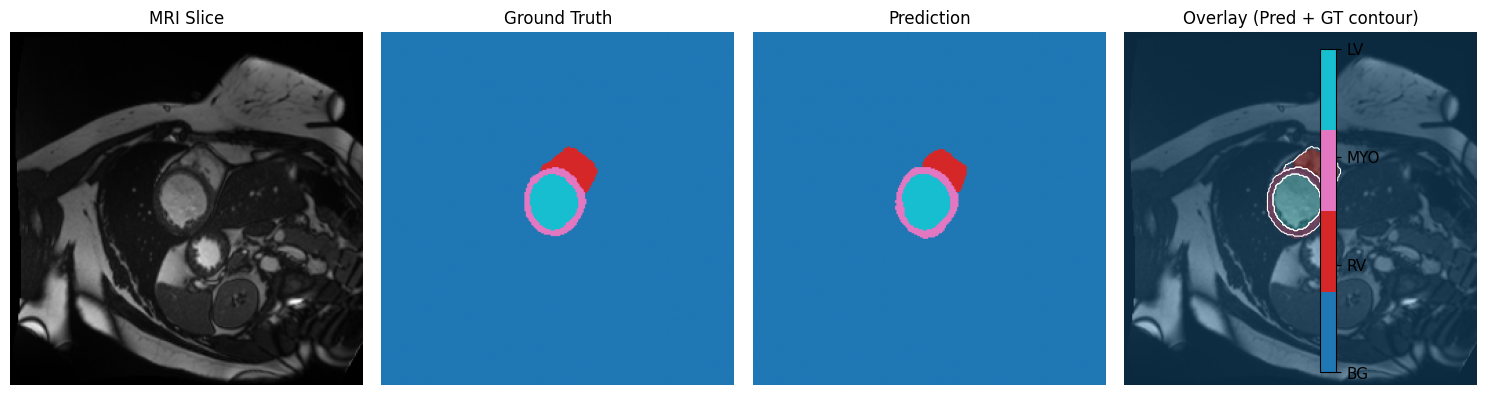


Fold=0 | Patient=patient102 | Phase=ED | Slice z=4/7 | BestEpoch=59
GT labels present   : [0 1 2 3] => ['BG', 'RV', 'MYO', 'LV']
Pred labels present : [0 1 2 3] => ['BG', 'RV', 'MYO', 'LV']
GT pixel counts     : {'BG': 64117, 'RV': 382, 'MYO': 406, 'LV': 631}
Pred pixel counts   : {'BG': 64110, 'RV': 336, 'MYO': 504, 'LV': 586}


C:\Users\manoj\AppData\Local\Temp\ipykernel_27640\627941098.py:178: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", N_CLASSES)
C:\Users\manoj\AppData\Local\Temp\ipykernel_27640\627941098.py:216: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


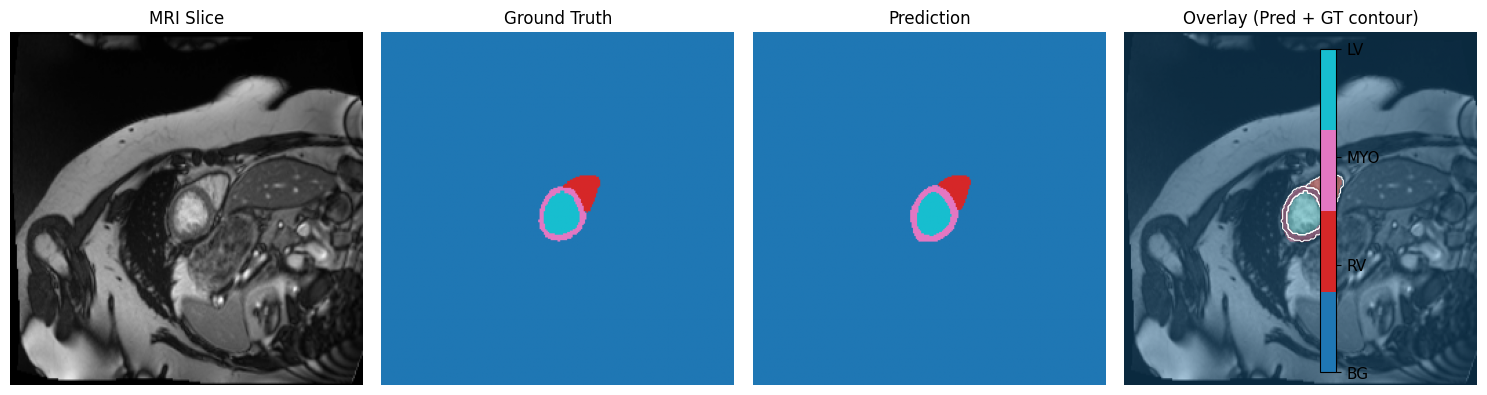


Fold=0 | Patient=patient103 | Phase=ED | Slice z=4/8 | BestEpoch=59
GT labels present   : [0 1 2 3] => ['BG', 'RV', 'MYO', 'LV']
Pred labels present : [0 1 2 3] => ['BG', 'RV', 'MYO', 'LV']
GT pixel counts     : {'BG': 62838, 'RV': 391, 'MYO': 982, 'LV': 1325}
Pred pixel counts   : {'BG': 63153, 'RV': 130, 'MYO': 996, 'LV': 1257}


C:\Users\manoj\AppData\Local\Temp\ipykernel_27640\627941098.py:178: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", N_CLASSES)
C:\Users\manoj\AppData\Local\Temp\ipykernel_27640\627941098.py:216: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


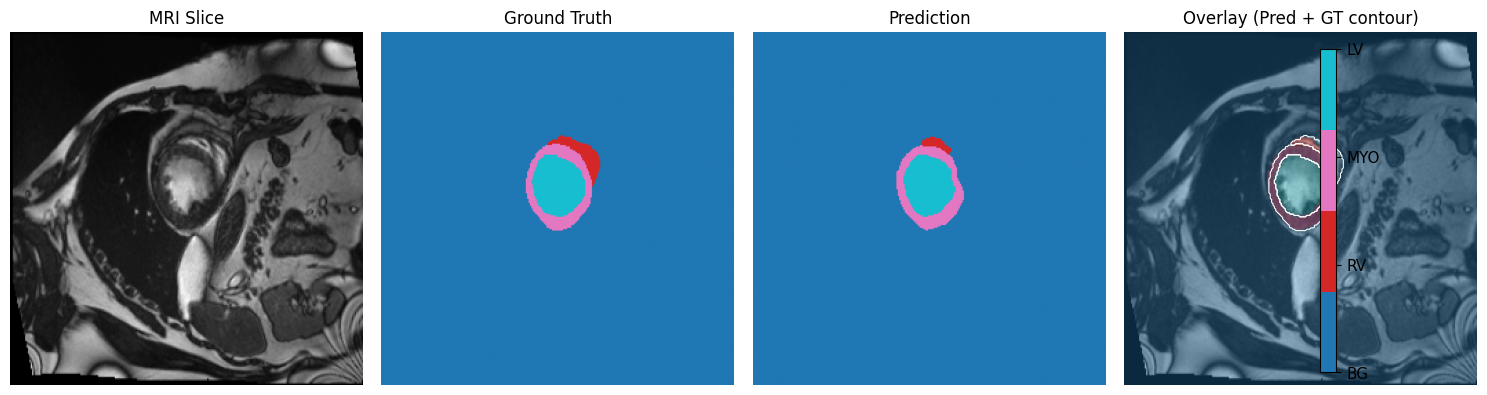

In [ ]:
# ============================================================
# QUALITATIVE VISUAL CHECK FOR TEST SAMPLES
# Shows image, GT, prediction, and overlay
# Also prints class presence and pixel counts
# ============================================================

from pathlib import Path
import json
import numpy as np
import nibabel as nib
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# REQUIRED MODEL CHECK
# ------------------------------------------------------------
if "UNet" not in globals():
    raise NameError("UNet is not defined. Run the U-Net model cell first.")

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------
ACDC_TEST_DIR = Path(r"c:\Users\manoj\Desktop\Thesis\ACDC\ACDC\database\testing")

# Option 1: choose experiment manually
# EXPERIMENT_DIR = Path(r"./runs_acdc_segmentation_experiments/unet_main_aug_fg_2slice_20260312_180315")

# Option 2: automatically use latest experiment
RUNS_ROOT = Path("./runs_acdc_segmentation_experiments")
if "EXPERIMENT_DIR" not in globals():
    experiment_dirs = sorted([p for p in RUNS_ROOT.iterdir() if p.is_dir()])
    if len(experiment_dirs) == 0:
        raise FileNotFoundError(f"No experiment folders found in {RUNS_ROOT.resolve()}")
    EXPERIMENT_DIR = experiment_dirs[-1]

print("Using experiment folder:", EXPERIMENT_DIR.resolve())

# choose fold
fold_idx = 0

# choose phase: "ed" or "es"
phase = "ed"

# choose slice mode: "middle" or "random"
slice_mode = "middle"

# choose which test patients to show
patient_indices = [0, 1, 2]

# image size
config_path = EXPERIMENT_DIR / "experiment_config.json"
if config_path.exists():
    with open(config_path, "r", encoding="utf-8") as f:
        exp_cfg = json.load(f)
    IMG_SIZE = int(exp_cfg.get("img_size", 256))
else:
    IMG_SIZE = 256

CLASS_NAMES = ["BG", "RV", "MYO", "LV"]
N_CLASSES = 4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------
def read_ed_es(info_cfg_path: Path):
    ed = None
    es = None
    for line in info_cfg_path.read_text().splitlines():
        line = line.strip()
        if line.startswith("ED:"):
            ed = int(line.split(":")[1].strip())
        elif line.startswith("ES:"):
            es = int(line.split(":")[1].strip())
    if ed is None or es is None:
        raise ValueError(f"Missing ED/ES in {info_cfg_path}")
    return ed, es

def load_nii(path):
    return nib.load(str(path)).get_fdata()

def zscore(x: np.ndarray) -> np.ndarray:
    x = x.astype(np.float32)
    return (x - x.mean()) / (x.std() + 1e-8)

def counts_per_class(mask, class_names):
    return {class_names[i]: int((mask == i).sum()) for i in range(len(class_names))}

# ------------------------------------------------------------
# LOAD CHECKPOINT
# ------------------------------------------------------------
fold_dir = EXPERIMENT_DIR / f"fold_{fold_idx:02d}"
if not fold_dir.exists():
    raise FileNotFoundError(f"Fold folder not found: {fold_dir}")

ckpt_candidates = sorted(fold_dir.glob(f"*_best_fold{fold_idx}.pth"))
if len(ckpt_candidates) == 0:
    raise FileNotFoundError(f"No best checkpoint found in {fold_dir}")

ckpt_path = ckpt_candidates[0]
print("Checkpoint:", ckpt_path.name)

ckpt = torch.load(ckpt_path, map_location=device)

model = UNet(in_channels=1, out_channels=4, bilinear=False).to(device)
model.load_state_dict(ckpt["model_state"])
model.eval()

# ------------------------------------------------------------
# BUILD TEST PATIENT LIST
# ------------------------------------------------------------
test_patients = sorted([p for p in ACDC_TEST_DIR.iterdir() if p.is_dir() and p.name.startswith("patient")])

if len(test_patients) == 0:
    raise FileNotFoundError(f"No patient folders found in {ACDC_TEST_DIR.resolve()}")

# ------------------------------------------------------------
# LOOP THROUGH SELECTED PATIENTS
# ------------------------------------------------------------
for patient_idx in patient_indices:
    pd = test_patients[patient_idx]
    pid = pd.name

    ed, es = read_ed_es(pd / "Info.cfg")
    frame = ed if phase.lower() == "ed" else es

    img_path = pd / f"{pid}_frame{frame:02d}.nii.gz"
    msk_path = pd / f"{pid}_frame{frame:02d}_gt.nii.gz"

    vol = load_nii(img_path)   # [H,W,S]
    msk = load_nii(msk_path)   # [H,W,S]

    S = vol.shape[2]
    if slice_mode == "random":
        z = np.random.randint(0, S)
    else:
        z = S // 2

    # original 2D slice
    img2d = zscore(vol[:, :, z]).astype(np.float32)
    gt2d = np.clip(msk[:, :, z].astype(np.int64), 0, N_CLASSES - 1)

    # resize to network input
    img_t = torch.from_numpy(img2d).unsqueeze(0).unsqueeze(0)   # [1,1,H,W]
    gt_t = torch.from_numpy(gt2d).unsqueeze(0).unsqueeze(0).float()

    img_t = F.interpolate(img_t, size=(IMG_SIZE, IMG_SIZE), mode="bilinear", align_corners=False)
    gt_t = F.interpolate(gt_t, size=(IMG_SIZE, IMG_SIZE), mode="nearest").long()

    img_in = img_t.to(device)
    gt_rs = gt_t.squeeze(0).squeeze(0).cpu().numpy()

    # prediction
    with torch.no_grad():
        logits = model(img_in)
        pred = torch.argmax(logits, dim=1)[0]

    pred_rs = pred.cpu().numpy().astype(np.int64)

    # print presence and counts
    gt_labels = np.unique(gt_rs)
    pred_labels = np.unique(pred_rs)

    print("\n" + "=" * 100)
    print(
        f"Fold={fold_idx} | Patient={pid} | Phase={phase.upper()} | "
        f"Slice z={z}/{S-1} | BestEpoch={ckpt.get('epoch', '?')}"
    )
    print("GT labels present   :", gt_labels, "=>", [CLASS_NAMES[i] for i in gt_labels])
    print("Pred labels present :", pred_labels, "=>", [CLASS_NAMES[i] for i in pred_labels])
    print("GT pixel counts     :", counts_per_class(gt_rs, CLASS_NAMES))
    print("Pred pixel counts   :", counts_per_class(pred_rs, CLASS_NAMES))

    # plot
    cmap = plt.cm.get_cmap("tab10", N_CLASSES)

    fig = plt.figure(figsize=(15, 4.2), facecolor="white")

    # image
    ax1 = fig.add_subplot(1, 4, 1)
    ax1.imshow(img_t.squeeze().cpu().numpy(), cmap="gray")
    ax1.set_title("MRI Slice", fontsize=12)
    ax1.axis("off")

    # GT
    ax2 = fig.add_subplot(1, 4, 2)
    im2 = ax2.imshow(gt_rs, cmap=cmap, vmin=0, vmax=N_CLASSES - 1)
    ax2.set_title("Ground Truth", fontsize=12)
    ax2.axis("off")

    # prediction
    ax3 = fig.add_subplot(1, 4, 3)
    ax3.imshow(pred_rs, cmap=cmap, vmin=0, vmax=N_CLASSES - 1)
    ax3.set_title("Prediction", fontsize=12)
    ax3.axis("off")

    # overlay
    ax4 = fig.add_subplot(1, 4, 4)
    ax4.imshow(img_t.squeeze().cpu().numpy(), cmap="gray")
    ax4.imshow(pred_rs, cmap=cmap, alpha=0.35, vmin=0, vmax=N_CLASSES - 1)

    # GT contours for foreground classes
    for c in [1, 2, 3]:
        ax4.contour((gt_rs == c).astype(np.uint8), levels=[0.5], colors="white", linewidths=0.8)

    ax4.set_title("Overlay (Pred + GT contour)", fontsize=12)
    ax4.axis("off")

    cbar = plt.colorbar(im2, ax=[ax1, ax2, ax3, ax4], fraction=0.02, pad=0.02)
    cbar.set_ticks([0, 1, 2, 3])
    cbar.set_ticklabels(CLASS_NAMES)

    plt.tight_layout()
    plt.show()

In [ ]:
# ============================================================
# THESIS TABLES FOR VALIDATION AND TEST METRICS
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# CHOOSE EXPERIMENT FOLDER
# ------------------------------------------------------------
# Option 1: set manually
# EXPERIMENT_DIR = Path(r"./runs_acdc_segmentation_experiments/unet_main_aug_fg_2slice_20260312_180315")

# Option 2: latest experiment
RUNS_ROOT = Path("./runs_acdc_segmentation_experiments")
experiment_dirs = sorted([p for p in RUNS_ROOT.iterdir() if p.is_dir()])
if len(experiment_dirs) == 0:
    raise FileNotFoundError(f"No experiment folders found in {RUNS_ROOT.resolve()}")

EXPERIMENT_DIR = experiment_dirs[-1]
print("Using experiment folder:", EXPERIMENT_DIR.resolve())

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------
VAL_CSV = EXPERIMENT_DIR / "cv_summary_per_fold.csv"
TEST_CSV = EXPERIMENT_DIR / "test_evaluation_paper_style" / "paper_style_test_results_per_fold.csv"

if not VAL_CSV.exists():
    raise FileNotFoundError(f"Validation summary file not found: {VAL_CSV}")

if not TEST_CSV.exists():
    raise FileNotFoundError(f"Test summary file not found: {TEST_CSV}")

val_df = pd.read_csv(VAL_CSV)
test_df = pd.read_csv(TEST_CSV)

TABLE_OUT_DIR = EXPERIMENT_DIR / "thesis_tables"
TABLE_OUT_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------
def mean_std(x):
    x = np.array(x, dtype=np.float64)
    mean = float(np.mean(x))
    std = float(np.std(x, ddof=1)) if len(x) > 1 else 0.0
    return mean, std

def fmt_metric(x, digits=4):
    m, s = mean_std(x)
    return f"{m:.{digits}f} ± {s:.{digits}f}"

# ------------------------------------------------------------
# 1) VALIDATION TABLE
# This comes from cross-fold validation during training
# ------------------------------------------------------------
validation_table = pd.DataFrame({
    "Metric": ["BG Dice", "RV Dice", "MYO Dice", "LV Dice", "Mean Dice"],
    "Validation (mean ± std)": [
        fmt_metric(val_df["dice_bg"].values),
        fmt_metric(val_df["dice_rv"].values),
        fmt_metric(val_df["dice_myo"].values),
        fmt_metric(val_df["dice_lv"].values),
        fmt_metric(val_df["fg_dice"].values),
    ]
})

print("\n" + "=" * 80)
print("VALIDATION METRICS TABLE")
print("=" * 80)
print(validation_table.to_string(index=False))

validation_table.to_csv(TABLE_OUT_DIR / "validation_metrics_table.csv", index=False)

# ------------------------------------------------------------
# 2) TEST TABLE (paper style)
# ------------------------------------------------------------
test_table = pd.DataFrame({
    "Phase": ["Overall", "ED", "ES"],
    "RV Dice": [
        fmt_metric(test_df["overall_rv_dice"].values),
        fmt_metric(test_df["ed_rv_dice"].values),
        fmt_metric(test_df["es_rv_dice"].values),
    ],
    "MYO Dice": [
        fmt_metric(test_df["overall_myo_dice"].values),
        fmt_metric(test_df["ed_myo_dice"].values),
        fmt_metric(test_df["es_myo_dice"].values),
    ],
    "LV Dice": [
        fmt_metric(test_df["overall_lv_dice"].values),
        fmt_metric(test_df["ed_lv_dice"].values),
        fmt_metric(test_df["es_lv_dice"].values),
    ],
    "Mean Dice": [
        fmt_metric(test_df["overall_mean_dice"].values),
        fmt_metric(test_df["ed_mean_dice"].values),
        fmt_metric(test_df["es_mean_dice"].values),
    ]
})

print("\n" + "=" * 80)
print("TEST METRICS TABLE")
print("=" * 80)
print(test_table.to_string(index=False))

test_table.to_csv(TABLE_OUT_DIR / "test_metrics_table.csv", index=False)

# ------------------------------------------------------------
# 3) COMBINED THESIS TABLE
# Validation + Test Overall in one compact table
# ------------------------------------------------------------
combined_table = pd.DataFrame({
    "Metric": ["RV Dice", "MYO Dice", "LV Dice", "Mean Dice"],
    "Validation": [
        fmt_metric(val_df["dice_rv"].values),
        fmt_metric(val_df["dice_myo"].values),
        fmt_metric(val_df["dice_lv"].values),
        fmt_metric(val_df["fg_dice"].values),
    ],
    "Test (Overall)": [
        fmt_metric(test_df["overall_rv_dice"].values),
        fmt_metric(test_df["overall_myo_dice"].values),
        fmt_metric(test_df["overall_lv_dice"].values),
        fmt_metric(test_df["overall_mean_dice"].values),
    ]
})

print("\n" + "=" * 80)
print("COMBINED VALIDATION + TEST TABLE")
print("=" * 80)
print(combined_table.to_string(index=False))

combined_table.to_csv(TABLE_OUT_DIR / "combined_validation_test_table.csv", index=False)

# ------------------------------------------------------------
# 4) MARKDOWN TABLES
# ------------------------------------------------------------
print("\n" + "=" * 80)
print("MARKDOWN - VALIDATION TABLE")
print("=" * 80)
print(validation_table.to_markdown(index=False))

print("\n" + "=" * 80)
print("MARKDOWN - TEST TABLE")
print("=" * 80)
print(test_table.to_markdown(index=False))

print("\n" + "=" * 80)
print("MARKDOWN - COMBINED TABLE")
print("=" * 80)
print(combined_table.to_markdown(index=False))


# ------------------------------------------------------------
# 6) SAVE TEXT VERSIONS
# ------------------------------------------------------------
(TABLE_OUT_DIR / "validation_metrics_table.txt").write_text(
    validation_table.to_string(index=False), encoding="utf-8"
)

(TABLE_OUT_DIR / "test_metrics_table.txt").write_text(
    test_table.to_string(index=False), encoding="utf-8"
)

(TABLE_OUT_DIR / "combined_validation_test_table.txt").write_text(
    combined_table.to_string(index=False), encoding="utf-8"
)

print("\nSaved tables to:", TABLE_OUT_DIR.resolve())

Using experiment folder: C:\Users\manoj\Desktop\Thesis\16873796\runs_acdc_segmentation_experiments\unet_main_aug_fg_2slice_20260312_180315

VALIDATION METRICS TABLE
   Metric Validation (mean ± std)
  BG Dice         0.9974 ± 0.0003
  RV Dice         0.8853 ± 0.0111
 MYO Dice         0.8572 ± 0.0172
  LV Dice         0.9390 ± 0.0102
Mean Dice         0.8939 ± 0.0118

TEST METRICS TABLE
  Phase         RV Dice        MYO Dice         LV Dice       Mean Dice
Overall 0.8877 ± 0.0049 0.8451 ± 0.0228 0.9343 ± 0.0165 0.8891 ± 0.0139
     ED 0.9088 ± 0.0045 0.8447 ± 0.0186 0.9477 ± 0.0152 0.9004 ± 0.0122
     ES 0.8516 ± 0.0065 0.8455 ± 0.0268 0.9090 ± 0.0197 0.8687 ± 0.0161

COMBINED VALIDATION + TEST TABLE
   Metric      Validation  Test (Overall)
  RV Dice 0.8853 ± 0.0111 0.8877 ± 0.0049
 MYO Dice 0.8572 ± 0.0172 0.8451 ± 0.0228
  LV Dice 0.9390 ± 0.0102 0.9343 ± 0.0165
Mean Dice 0.8939 ± 0.0118 0.8891 ± 0.0139

MARKDOWN - VALIDATION TABLE
| Metric    | Validation (mean ± std)   |
|:------

### U-Net Structure (Thesis Report )

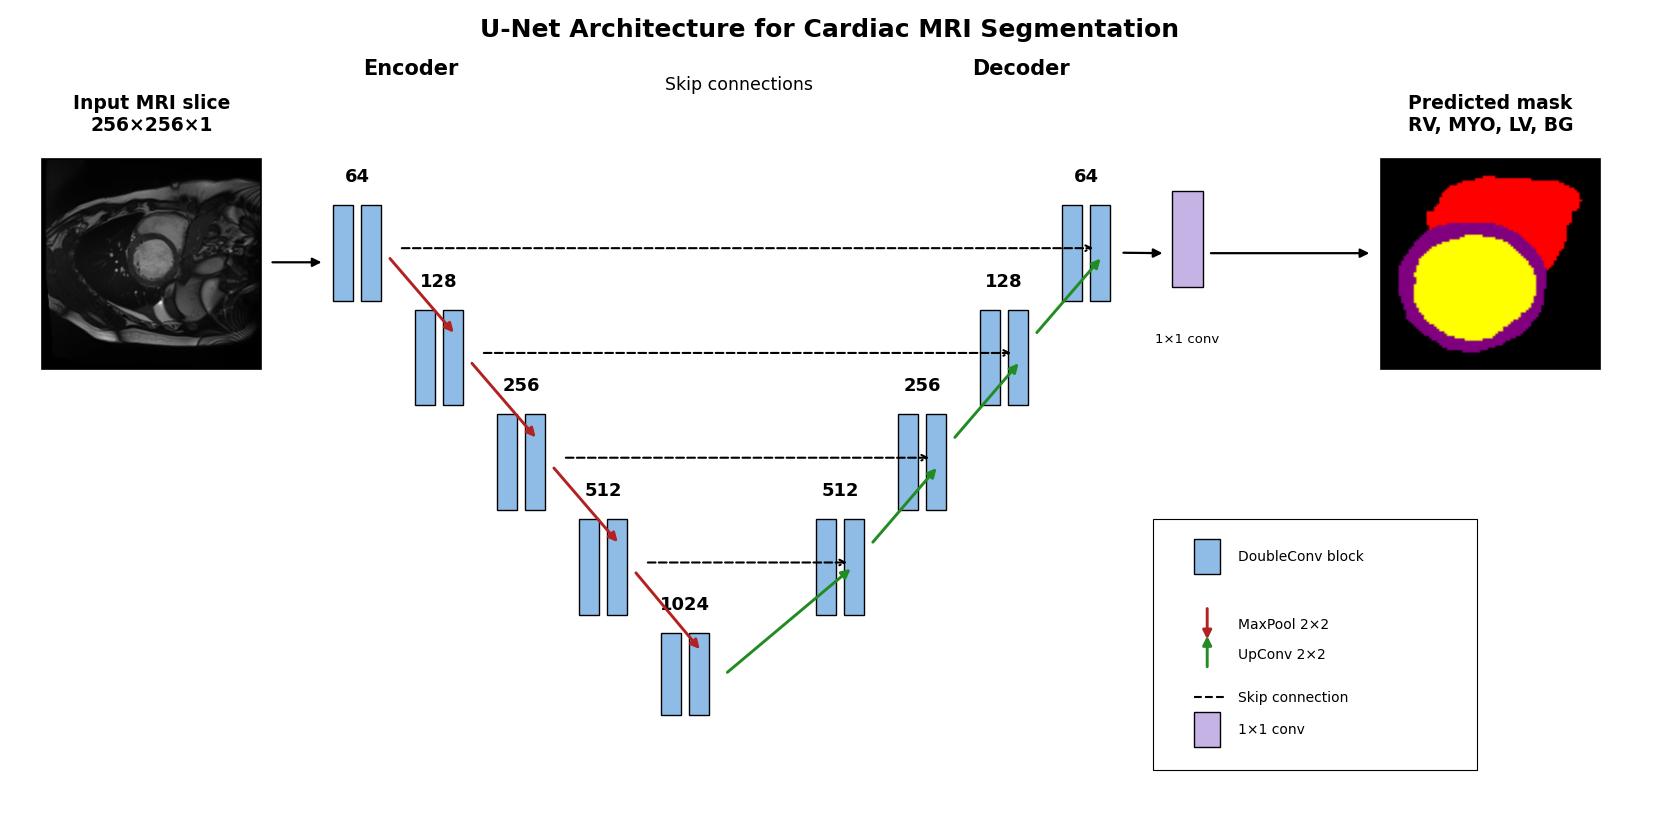

Saved PNG to: C:\Users\manoj\Desktop\Thesis\16873796\Models\figure_3_2_unet_architecture_real_final.png
Saved PDF to: C:\Users\manoj\Desktop\Thesis\16873796\Models\figure_3_2_unet_architecture_real_final.pdf


In [4]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch
from matplotlib.lines import Line2D
import matplotlib.image as mpimg
from pathlib import Path
import numpy as np


def crop_non_black_region(img, margin=18, threshold=0.03):
    """
    Crop an image around non-black content.

    This is especially useful for the output segmentation mask, where the
    heart segmentation may occupy a small area inside a large black background.

    Works for grayscale, RGB, or RGBA images.
    """
    arr = np.asarray(img)

    # Convert possible 0--255 image to 0--1
    if arr.dtype != np.float32 and arr.dtype != np.float64:
        arr_float = arr.astype(np.float32) / 255.0
    else:
        arr_float = arr.astype(np.float32)

    if arr_float.ndim == 2:
        content_mask = arr_float > threshold
    else:
        rgb = arr_float[..., :3]
        content_mask = np.any(rgb > threshold, axis=-1)

        # If image has alpha channel, ignore fully transparent pixels
        if arr_float.shape[-1] == 4:
            alpha = arr_float[..., 3]
            content_mask = content_mask & (alpha > threshold)

    rows, cols = np.where(content_mask)

    if len(rows) == 0 or len(cols) == 0:
        return img

    y0 = max(rows.min() - margin, 0)
    y1 = min(rows.max() + margin + 1, arr.shape[0])
    x0 = max(cols.min() - margin, 0)
    x1 = min(cols.max() + margin + 1, arr.shape[1])

    return arr[y0:y1, x0:x1]


def draw_unet_figure_with_real_images(
    input_img_path,
    output_img_path,
    save_png="figure_3_2_unet_architecture_real_final.png",
    save_pdf="figure_3_2_unet_architecture_real_final.pdf",
    crop_output_mask=True
):
    # ------------------------------------------------------------
    # Paths
    # ------------------------------------------------------------
    input_img_path = Path(input_img_path)
    output_img_path = Path(output_img_path)
    save_png = Path(save_png)
    save_pdf = Path(save_pdf)

    if not input_img_path.exists():
        raise FileNotFoundError(f"Input image not found:\n{input_img_path}")

    if not output_img_path.exists():
        raise FileNotFoundError(f"Output mask image not found:\n{output_img_path}")

    save_png.parent.mkdir(parents=True, exist_ok=True)
    save_pdf.parent.mkdir(parents=True, exist_ok=True)

    # ------------------------------------------------------------
    # Load real input MRI slice and output mask
    # ------------------------------------------------------------
    input_img = mpimg.imread(input_img_path)
    output_img = mpimg.imread(output_img_path)

    # Crop/zoom the output mask so RV/MYO/LV are clearly visible
    if crop_output_mask:
        output_img = crop_non_black_region(output_img, margin=18, threshold=0.03)

    # ------------------------------------------------------------
    # Figure setup
    # ------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(18, 8.5))
    ax.set_xlim(0, 18)
    ax.set_ylim(0, 9)
    ax.axis("off")

    # ------------------------------------------------------------
    # Helper functions
    # ------------------------------------------------------------
    def rect(x, y, w, h, color="#8FBCE6", edge="black", lw=1.0, zorder=1):
        box = Rectangle(
            (x, y),
            w,
            h,
            facecolor=color,
            edgecolor=edge,
            linewidth=lw,
            zorder=zorder
        )
        ax.add_patch(box)
        return box

    def arrow(
        x1,
        y1,
        x2,
        y2,
        color="black",
        lw=1.6,
        dashed=False,
        style="-|>",
        mutation=13,
        zorder=5
    ):
        arr = FancyArrowPatch(
            (x1, y1),
            (x2, y2),
            arrowstyle=style,
            mutation_scale=mutation,
            linewidth=lw,
            color=color,
            linestyle="--" if dashed else "-",
            zorder=zorder
        )
        ax.add_patch(arr)
        return arr

    def double_conv_block(x, y, channels, height=1.05):
        # Two blue rectangles represent one DoubleConv block
        rect(x, y, 0.22, height, color="#8FBCE6", lw=1.0)
        rect(x + 0.30, y, 0.22, height, color="#8FBCE6", lw=1.0)

        ax.text(
            x + 0.26,
            y + height + 0.22,
            str(channels),
            ha="center",
            va="bottom",
            fontsize=13,
            fontweight="bold"
        )

        return x + 0.52, y + height / 2

    # ------------------------------------------------------------
    # Title and section labels
    # ------------------------------------------------------------
    ax.text(
        9,
        8.78,
        "U-Net Architecture for Cardiac MRI Segmentation",
        ha="center",
        va="center",
        fontsize=18,
        fontweight="bold"
    )

    ax.text(
        4.4,
        8.35,
        "Encoder",
        ha="center",
        va="center",
        fontsize=15,
        fontweight="bold"
    )

    ax.text(
        11.1,
        8.35,
        "Decoder",
        ha="center",
        va="center",
        fontsize=15,
        fontweight="bold"
    )

    ax.text(
        8.0,
        8.18,
        "Skip connections",
        ha="center",
        va="center",
        fontsize=12.5
    )

    # ------------------------------------------------------------
    # Larger real input MRI image
    # ------------------------------------------------------------
    input_x0, input_x1 = 0.35, 2.75
    input_y0, input_y1 = 5.05, 7.35

    ax.imshow(
        input_img,
        extent=(input_x0, input_x1, input_y0, input_y1),
        zorder=2
    )

    rect(
        input_x0,
        input_y0,
        input_x1 - input_x0,
        input_y1 - input_y0,
        color="none",
        lw=1.2,
        zorder=3
    )

    ax.text(
        (input_x0 + input_x1) / 2,
        input_y1 + 0.28,
        "Input MRI slice\n256×256×1",
        ha="center",
        va="bottom",
        fontsize=13.5,
        fontweight="bold"
    )

    # ------------------------------------------------------------
    # Encoder blocks
    # ------------------------------------------------------------
    enc64 = double_conv_block(3.55, 5.80, 64)
    enc128 = double_conv_block(4.45, 4.65, 128)
    enc256 = double_conv_block(5.35, 3.50, 256)
    enc512 = double_conv_block(6.25, 2.35, 512)
    enc1024 = double_conv_block(7.15, 1.25, 1024, height=0.90)

    # ------------------------------------------------------------
    # Decoder blocks
    # ------------------------------------------------------------
    dec512 = double_conv_block(8.85, 2.35, 512)
    dec256 = double_conv_block(9.75, 3.50, 256)
    dec128 = double_conv_block(10.65, 4.65, 128)
    dec64 = double_conv_block(11.55, 5.80, 64)

    # ------------------------------------------------------------
    # Main flow arrows
    # ------------------------------------------------------------
    arrow(input_x1 + 0.10, 6.22, 3.45, 6.22)

    # Downsampling arrows
    down_pairs = [
        (enc64, enc128),
        (enc128, enc256),
        (enc256, enc512),
        (enc512, enc1024),
    ]

    for (x1, y1), (x2, y2) in down_pairs:
        arrow(
            x1 + 0.08,
            y1 - 0.04,
            x2 - 0.08,
            y2 + 0.25,
            color="#B22222",
            lw=2.1
        )

    # Bottleneck to decoder
    arrow(
        enc1024[0] + 0.18,
        enc1024[1],
        dec512[0] - 0.12,
        dec512[1],
        color="#228B22",
        lw=2.1
    )

    # Upsampling arrows
    up_pairs = [
        (dec512, dec256),
        (dec256, dec128),
        (dec128, dec64),
    ]

    for (x1, y1), (x2, y2) in up_pairs:
        arrow(
            x1 + 0.08,
            y1 + 0.25,
            x2 - 0.08,
            y2 - 0.04,
            color="#228B22",
            lw=2.1
        )

    # Skip connections
    skip_pairs = [
        (enc64, dec64),
        (enc128, dec128),
        (enc256, dec256),
        (enc512, dec512),
    ]

    for (x1, y1), (x2, y2) in skip_pairs:
        arrow(
            x1 + 0.20,
            y1 + 0.05,
            x2 - 0.15,
            y2 + 0.05,
            color="black",
            lw=1.5,
            dashed=True,
            style="->",
            mutation=10
        )

    # ------------------------------------------------------------
    # Final 1x1 convolution
    # ------------------------------------------------------------
    rect(12.75, 5.95, 0.34, 1.05, color="#C6B3E6", lw=1.0)

    ax.text(
        12.92,
        5.45,
        "1×1 conv",
        ha="center",
        va="top",
        fontsize=9.5
    )

    arrow(dec64[0] + 0.12, dec64[1], 12.68, 6.32)
    arrow(13.15, 6.32, 14.95, 6.32)

    # ------------------------------------------------------------
    # Larger and zoomed output segmentation mask
    # ------------------------------------------------------------
    output_x0, output_x1 = 15.05, 17.45
    output_y0, output_y1 = 5.05, 7.35

    ax.imshow(
        output_img,
        extent=(output_x0, output_x1, output_y0, output_y1),
        zorder=2
    )

    rect(
        output_x0,
        output_y0,
        output_x1 - output_x0,
        output_y1 - output_y0,
        color="none",
        lw=1.2,
        zorder=3
    )

    ax.text(
        (output_x0 + output_x1) / 2,
        output_y1 + 0.28,
        "Predicted mask\nRV, MYO, LV, BG",
        ha="center",
        va="bottom",
        fontsize=13.5,
        fontweight="bold"
    )

    ax.text(
        (output_x0 + output_x1) / 2,
        output_y0 - 0.18,
        "",
        ha="center",
        va="top",
        fontsize=9.5
    )

    # ------------------------------------------------------------
    # Legend
    # ------------------------------------------------------------
    legend_x = 13.00
    legend_y = 1.10

    rect(
        legend_x - 0.45,
        legend_y - 0.45,
        3.55,
        2.75,
        color="white",
        lw=0.8,
        zorder=0
    )

    rect(legend_x, legend_y + 1.70, 0.28, 0.38, color="#8FBCE6")
    ax.text(
        legend_x + 0.48,
        legend_y + 1.90,
        "DoubleConv block",
        va="center",
        fontsize=10
    )

    arrow(
        legend_x + 0.14,
        legend_y + 1.35,
        legend_x + 0.14,
        legend_y + 0.95,
        color="#B22222",
        lw=2.1
    )
    ax.text(
        legend_x + 0.48,
        legend_y + 1.15,
        "MaxPool 2×2",
        va="center",
        fontsize=10
    )

    arrow(
        legend_x + 0.14,
        legend_y + 0.65,
        legend_x + 0.14,
        legend_y + 1.05,
        color="#228B22",
        lw=2.1
    )
    ax.text(
        legend_x + 0.48,
        legend_y + 0.82,
        "UpConv 2×2",
        va="center",
        fontsize=10
    )

    ax.add_line(
        Line2D(
            [legend_x, legend_x + 0.32],
            [legend_y + 0.35, legend_y + 0.35],
            linestyle="--",
            color="black",
            linewidth=1.5
        )
    )
    ax.text(
        legend_x + 0.48,
        legend_y + 0.35,
        "Skip connection",
        va="center",
        fontsize=10
    )

    rect(legend_x, legend_y - 0.20, 0.28, 0.38, color="#C6B3E6")
    ax.text(
        legend_x + 0.48,
        legend_y,
        "1×1 conv",
        va="center",
        fontsize=10
    )

    # ------------------------------------------------------------
    # Save
    # ------------------------------------------------------------
    plt.tight_layout()

    fig.savefig(
        save_png,
        dpi=450,
        bbox_inches="tight",
        facecolor="white",
        pad_inches=0.03
    )

    fig.savefig(
        save_pdf,
        dpi=450,
        bbox_inches="tight",
        facecolor="white",
        pad_inches=0.03
    )

    plt.show()

    print(f"Saved PNG to: {save_png}")
    print(f"Saved PDF to: {save_pdf}")


# ------------------------------------------------------------
# Run this
# ------------------------------------------------------------
draw_unet_figure_with_real_images(
    input_img_path=r"C:\Users\manoj\Desktop\Thesis\16873796\Models\unet_input_slice.png",
    output_img_path=r"C:\Users\manoj\Desktop\Thesis\16873796\Models\unet_output_mask.png",
    save_png=r"C:\Users\manoj\Desktop\Thesis\16873796\Models\figure_3_2_unet_architecture_real_final.png",
    save_pdf=r"C:\Users\manoj\Desktop\Thesis\16873796\Models\figure_3_2_unet_architecture_real_final.pdf",
    crop_output_mask=True
)